<style>
    /* Global styles to make the notebook completely stunning */
    blockquote {
        background: #f4f9f9;
        border-left: 5px solid #2980b9;
        padding: 15px 20px;
        margin: 20px 0;
        border-radius: 0 8px 8px 0;
        color: #34495e;
        box-shadow: 0 2px 4px rgba(0,0,0,0.05);
    }
    ul, ol {
        background: #fdfdfd;
        padding: 15px 15px 15px 35px;
        border-radius: 8px;
        border: 1px solid #eef2f3;
        box-shadow: 0 1px 3px rgba(0,0,0,0.02);
    }
    li {
        margin-bottom: 8px;
        color: #2c3e50;
    }
</style>

#
<div style="background: linear-gradient(135deg, #1e3c72 0%, #2a5298 100%); padding: 30px; border-radius: 12px; margin-bottom: 25px; box-shadow: 0 8px 20px rgba(0,0,0,0.15);"><h1 style="color: #ffffff; margin: 0; text-align: center; text-transform: uppercase; letter-spacing: 3px; font-weight: 800; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">Energy-Based AI Models (EBMs)</h1></div>

##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">Introduction</h2></div>



<div class="text-center" align="center">
<img src="Utils/gases.gif" alt="Gas Animation" width="50%">
</div>

Imagine a gas of molecules in a container held at a constant temperature $T$. If you take a picture of the container, you will find the molecules in a particular configuration which is most likely different from another configuration or picture taken at another time. 

In statistical physics after the pioneering works of Ludwig Boltzmann and J. Willard Gibbs, <span style="color:red;"><strong>the probability density of finding this gas in a particular configuration</strong></span> is determined by its total energy $U$ and is given by the following equation
$$
p = \frac{1}{Z} e^{-U/T}
$$
where $Z$ is called the partition function and is actually a constant. Its job is to make sure that the sum of the probabilities is equal to 1. 

Interestingly, due to the glory of physics, <span style="color:red;"><strong>this equation describes the probability density of any other physical system held at a constant temperature</strong></span> $T$. That means for example if we are dealing with a magnet made of atoms that can have spins up or down (shown as black or white pixels in the animation below), the total energy of the magnet $U$ will determine the probability of its configuration. 

<div class="text-center" align="center">
<img src="Utils/Ising_model.gif?t=1783027522" alt="Ising model" width="40%">
</div>


More interestingly, due to glory of nature, <span style="color:red;"><strong>this same probability density seem to explain most other non-physical systems</strong></span> due to something called <span style="color:red;"><strong>maximum entropy principle</strong></span> which is the counterpart of the <span style="color:red;"><strong>2nd law of thermodynamics</strong></span> in physics. You don't need to learn these principle and law in this course. Just keep them in mind and memorize the form of the probability density above. 

Let me explain what I mean when I say the probability density of a non-physical system is given by the equation above.

Imagine you have a dataset consisting of house properties and prices


<div class="text-center" align="center">
<img src="Utils/house_prices_head.png" alt="House Prices Head" width="75%">
</div>


<span style="color:red;"><strong>Each row of this dataset is a configuration of the housing system</strong></span> just like each image of the gas container was a configuration of that system. That means the so-called energy of the housing system is <span style="color:red;"><strong>a function of one row of this dataset</strong></span>
$$
U = U(x) 
$$
where $x \in \mathbb{R}^d$

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Example</h3>

Let's assume our dataset has only <span style="color:red;"><strong>one column</strong></span> which we refer to it using $x$. We also assume the <span style="color:red;"><strong>energy of our system has the following form</strong></span>

$$
U(x)=\log\left[0.7 \exp\left(- x^2 \right) + 0.3 \exp\left(-\frac{(x-5)^{2}}{0.25}\right)\right]
$$

which we have plotted below

<div class="text-center" align="center">
<img src="Utils/gaussian_energy.png?t=1783024690" alt="Gaussian Energy" width="50%">
</div>

In this plot, the y-axis shows the energy. The x-axis shows different configurations (possible rows in the dataset). If we have a dataset of 2 columns, then we had to make a 3D plot showing one column as $x_1$ and the other column as $x_2$. Here for simplicity we stick to a 1-dimensional system. 


If we <span style="color:red;"><strong>insert this energy to the probability density function</strong></span> 
$$
p(x) = \frac{1}{Z} e^{-U(x)/T}
$$
and compute $Z$ using the following equation which is just making sure the total sum of the probabilities is 1
$$
Z = \int dx\, e^{-U(x)/T}
$$

then I can also plot the probability density of this same system

<div class="text-center" align="center">
<img src="Utils/gaussian_prob.png?t=1783026479" alt="Gaussian Probability Density" width="50%">
</div>


If you <span style="color:red;"><strong>compare the locations of minima of the energy with the maxima of the probability density</strong></span> you will see that they happen to be <span style="color:red;"><strong>exactly</strong></span> at the same position on the x-axis. 

Since the maxima of the probability density are just the most likely configurations of the system, that means <span style="color:red;"><strong>most of the rows of the dataset happen to be in these locations</strong></span> or very close to. 

In other words, most of the rows of the dataset happen to have $x$ that are very close to those $x$ at which the probabilities are maxima and energies are minima. Given that the energy is negative logarithm of the probability, the distances between rows of dataset and energy minima are almost always close to zero. 

That means if I want to use energies for prediction purposes, <span style="color:red;"><strong>my prediction for the next row of the dataset would be just the x-value of the deepest minimum of the energy function.</strong></span> 

And that is mostly the concept behind EBMs. But, prediction is not the only task EBMs can do. The more modern use case of EBMs is generative modeling, i.e. the same task as what Google's Nano Banana and GPT-image currently do using diffusion models, which we will cover in future. 

We will discuss both prediction and generative models below. But, before that, let's wrap up this section by a take away message. 


###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Take away message:</h3>

Energy-Based Models (EBMs) are mathematical frameworks used to map the relationship between different variables in a row of a dataset. 

<span style="color:red;"><strong>Instead of directly calculating a probability, an EBMs assign a single scalar value called "energy" to every possible combination of variables</strong></span> (configurations of the system or simply possible rows of the dataset). 

* <span style="color:red;"><strong>Low Energy</strong></span> = The set of variables are highly compatible and the <span style="color:red;"><strong>configuration of the system is highly likely</strong></span>.
* <span style="color:red;"><strong>High Energy</strong></span> = The variables are incompatible and that <span style="color:red;"><strong>configuration of the system is unlikely</strong></span>.

#### The Big Advantage: Bypassing Normalization Constant $Z$


As you know, a valid probability density function must integrate to 1: 
$$\int_{\mathbb{R}^d} dx\, p(x) = 1$$

That means we have to define $Z$ as 
$$
Z = \int_{\mathbb{R}^d} dx\, e^{-U(x)/T}
$$
to guarantee this requirement. 


If $d$ is very large, i.e., <span style="color:red;"><strong>when our dataset has too many columns</strong></span>, computing $Z$ requires solving incredibly difficult, sometimes <span style="color:red;"><strong>impossible, high-dimensional integrals</strong></span>. 

<span style="color:red;"><strong>EBMs completely avoid this problem.</strong></span> Because inference only requires finding the deepest minimum of the energy function. 
In other generative models like the diffusion model (current most famous used case is image generation like in GPT-image), this $Z$ issue is handled differently. In short, <span style="color:red;"><strong>all generative models have to somehow handle this </strong></span>$Z$<span style="color:red;"><strong> computation</strong></span> and <span style="color:red;"><strong>EBMs solve the problem by simply throwing out </strong></span>$Z$<span style="color:red;"><strong>.</strong></span>

By removing the strict mathematical constraint of normalization, you are given significantly more freedom to design complex, flexible functions. In fact, standard probabilistic models can simply be viewed as a rigid sub-category of EBMs where the mathematical constraint of normalization is enforced.

In the following we briefly show the classic use cases of EBMs for regression and classification and then move on to the modern generative use case.

##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">Linear Regression with Energy-Based Models (EBMs)</h2></div>

<span style="color:red;"><strong>EBMs provide a unifying framework for most machine learning and also deep learning models.</strong></span> 

That means most machine learning models can be equivalently reformulated within the EBM framework, or in other words, the following equation will explain them all
$$
p = \frac{1}{Z} e^{-U/T}
$$

The difference between machine learning models is in the explicit form of their energy function $U$.

In this course, before getting into generative task of EBMs, I want to show <span style="color:red;"><strong>how linear regression, logistic regression and fully connected neural nets can be reformulated in the form of EBMs</strong></span>.

We start with linear regression and to make things obvious, let's work with the house dataset that we observed above.


Let me first download the <span style="color:red;"><strong>California housing dataset</strong></span> and store it in a dataframe. 

In [4]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the dataset
california_housing = fetch_california_housing(as_frame=True)

# The variables X are in `data`, and target variables Y are in `target`
df = california_housing.data

# Add the target (price) as the last column
df['HousePrice'] = california_housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Next we split the columns just like in a linear regression task. All the columns except the last one (house price) will be shown with $X$ and the last column is shown with $y$. 


In [5]:
X = df.drop('HousePrice', axis=1)
 
y = df['HousePrice']

<span style="color:red;"><strong>Our goal is to train an EBM that given the values of </strong></span>$X$<span style="color:red;"><strong> predicts </strong></span>$y$. In other words, we want to define an energy function $U_{\theta}(X, y)$ and optimize its free parameters $\theta$ such that if the values of $X$ are inserted into it, its deepest minimum will be at a $\hat{y}$ that is closest to the true $y$.

So, we define <span style="color:red;"><strong>the energy function</strong></span> as 
$$
U_{\theta}(X, y) = \frac{1}{2}||\theta_0 + \theta_1 X_1 + \cdots \theta_k X_k - y||^2
$$

where $X_1$<span style="color:red;"><strong> is the first columns labeled "MedInc" in the dataset and </strong></span>$X_2$<span style="color:red;"><strong> is "HouseAge"</strong></span>, etc. Also $y$<span style="color:red;"><strong> is just the last column "HousePrice"</strong></span>.

<span style="color:red;"><strong>To train this model we need to minimize a loss function.</strong></span> While there are different options available, we use the simplest one: the <span style="color:red;"><strong>energy loss</strong></span>, which is just the average energy across all training samples (all rows of the dataset)

$$
\mathcal{L} = \frac{1}{2 N}\sum_{i=1}^{N} U_{\theta}(X^{(i)}, y^{(i)})
$$

where $N$ is the total number of rows in the dataset above and $i$ is the index of the rows.

<span style="color:red;"><strong>And this is just the so called "Mean Squared Error (MSE)" which is the conventional loss function of linear regression.</strong></span> To see that, simply insert the right side of equation for $U_{\theta}(X, y)$ into the loss function above. 


<span style="color:red;"><strong>Let's minimize this loss function</strong></span> and find the optimal values of $\theta$.



In [6]:
from scipy.optimize import minimize
import numpy as np

# Scale the features nicely since California Housing variables have wildly different scales
# This helps the optimizer converge
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)
y_vals = y.values

# Energy function U_theta(X, y) which acts as our loss over the dataset
def energy_loss(theta, X, y):
    # theta[0] is the intercept, theta[1:] are the coefficients
    y_pred = theta[0] + np.dot(X, theta[1:])
    # U_theta = 1/2 * || y_pred - y ||^2
    energy = 0.5 * np.mean((y - y_pred) ** 2)
    return energy

# Define gradient of the energy loss
def energy_loss_jac(theta, X, y):
    y_pred = theta[0] + np.dot(X, theta[1:])
    diff = y_pred - y
    # Gradient w.r.t intercept
    grad_intercept = np.mean(diff)
    # Gradient w.r.t coefficients
    grad_coeffs = np.dot(X.T, diff) / len(y)
    return np.concatenate([[grad_intercept], grad_coeffs])

# Initialize theta (parameters) with zeros. 
# +1 to include the intercept
initial_theta = np.zeros(X_scaled.shape[1] + 1)

# Use scipy's minimize to find the optimal parameters
# Using BFGS and explicitly passing the Jacobian helps significantly with convergence
result = minimize(
    energy_loss, 
    initial_theta, 
    args=(X_scaled, y_vals),
    method='BFGS',
    jac=energy_loss_jac,
    options={'disp': False}
)

# Optimal parameters
theta_opt = result.x

print("Optimization Success:", result.success)
print("Message:", result.message)
print("Optimal theta:", theta_opt)

Optimization Success: True
Message: Optimization terminated successfully.
Optimal theta: [ 2.0685581   0.82961897  0.11874965 -0.26552958  0.30569709 -0.00450459
 -0.03932581 -0.89988975 -0.87054452]


Now that we have the optimal values of $\theta$, let's insert them into the function and <span style="color:red;"><strong>plot the energy function for all rows of the dataset</strong></span>

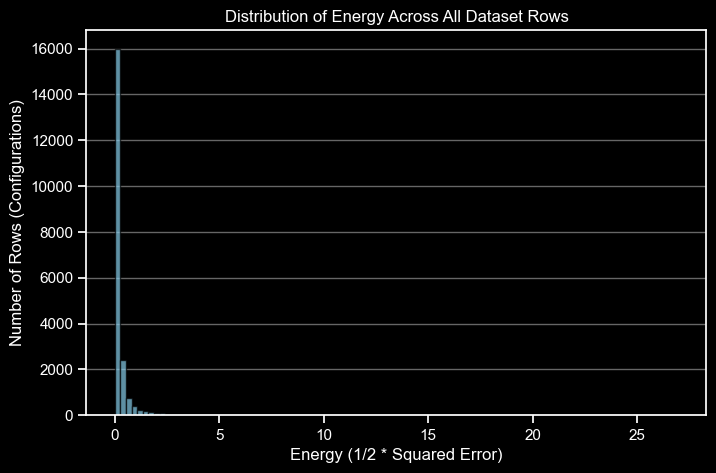

In [4]:
import matplotlib.pyplot as plt

# Calculate the predicted y values using the optimal theta
y_pred = theta_opt[0] + np.dot(X_scaled, theta_opt[1:])

# Calculate the energy for each individual row in the dataset
# U^(i) = 1/2 * (y_pred^(i) - y^(i))^2
energies = 0.5 * (y_pred - y_vals) ** 2

# Plot the distribution of energies
import requests
style = open("Utils/plot_style.py").read()
exec(style)
plt.figure(figsize=(8, 5))
plt.hist(energies, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Energy Across All Dataset Rows")
plt.xlabel("Energy (1/2 * Squared Error)")
plt.ylabel("Number of Rows (Configurations)")
plt.grid(axis='y', alpha=0.5)
plt.show()

As you can see, <span style="color:red;"><strong>most of the rows happen to have the lowest energy bin</strong></span> in the histogram. That means as I explained above, <span style="color:red;"><strong>the most probable configuration is the lowest energy possible</strong></span>. As we go toward higher energies the chance (frequency as represented by the hights of the bins in the histogram) of that configuration to actually occur goes down.

Ok, now let's get into <span style="color:red;"><strong>the prediction part</strong></span>. 

Let's get back to the form of the energy function 
$$
U_{\theta}(X, y) = \frac{1}{2}||\theta_0 + \theta_1 X_1 + \cdots \theta_k X_k - y||^2
$$

Due to the absolute value raised to the power of two, <span style="color:red;"><strong>the lowest energy possible in this equation is 0 and happens when</strong></span> 
$$
y = \theta_0 + \theta_1 X_1 + \cdots \theta_k X_k
$$

<span style="color:red;"><strong>This is just the famous equation for linear regression</strong></span>. Therefore, if we have the values of $X$ and optimal values of $\theta$, the right hand side is just a number and we take that as the prediction for $y$ which we now rephrase as $\hat{y}$ to distinguish from the actual variable $y$.

Let's now <span style="color:red;"><strong>compare our predictions with true values</strong></span>

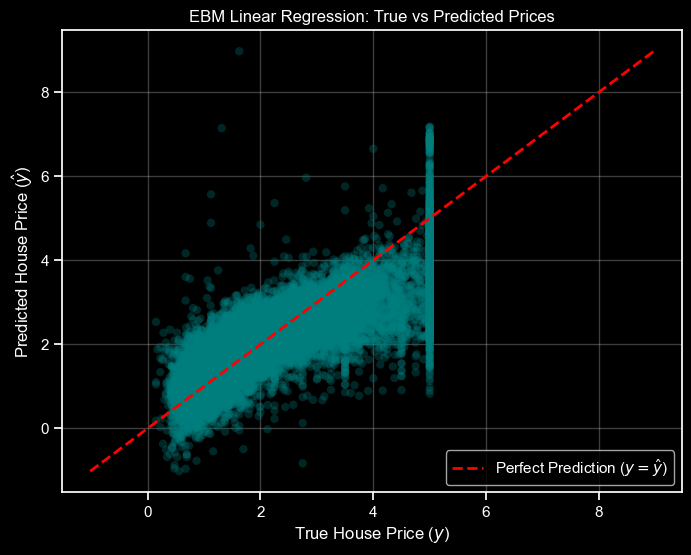

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate predictions using the optimal parameters
# Note: we use X_scaled because the model was trained on scaled features
y_pred = theta_opt[0] + np.dot(X_scaled, theta_opt[1:])

# Plot True vs Predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_vals, y_pred, alpha=0.3, color='teal', edgecolor='none')

# Plot a diagonal line for reference (where True = Predicted)
min_val = min(np.min(y_vals), np.min(y_pred))
max_val = max(np.max(y_vals), np.max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction ($y = \hat{y}$)')

plt.title("EBM Linear Regression: True vs Predicted Prices")
plt.xlabel("True House Price ($y$)")
plt.ylabel(r"Predicted House Price ($\hat{y}$)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

I should mention that in what we did above, <span style="color:red;"><strong>we did not split to train and test and we used the seen data to test the model</strong></span>. But, our purpose was just for demonstration and it is acceptable for now. 


Also, except the vertical line at the far right, which is perhaps because we <span style="color:red;"><strong>did not clean</strong></span> the data and <span style="color:red;"><strong>did not remove the outliers</strong></span>, the overall agreement is fine. 

##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">Two-Class Classification (Logistic Regression) with EBMs</h2></div>

In this section, I will show how logistic regression can be expressed within the EBM framework. 

To make things obvious, let's work with the Breast Cancer dataset.

Let me first download the <span style="color:red;"><strong>Breast Cancer Wisconsin dataset</strong></span> and store it in a dataframe.

In [6]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load the dataset
breast_cancer = load_breast_cancer(as_frame=True)

# The variables X are in `data`, and target variables Y are in `target`
df_cancer = breast_cancer.data

# Add the target (benign or malignant) as the last column
df_cancer['Target'] = breast_cancer.target
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Here, the columns are some properties of the breast tumors, and the last column is the class of the tumor wether it is benign or malignant. 
For real data science work, one needs to better understand the features. But, for this course, our goal is to demonstrate that logistic regression can be reformulated as an EBM. So, this level of info is enough. 

Next we split the columns just like in a logistic regression task. All the columns except the last one (Target: the class of the tumor) will be shown with $X$ and the last column is shown with $y$. 

First thing to note is that the corresponding energy form for the EBM formulation of logistic regression is much simpler if the classes are $\{-1, 1\}$, but the dataset targets are $\{0, 1\}$. <span style="color:red;"><strong>So, let's map </strong></span>$0 \to -1$.

Note that the it is only a matter of convention to label a class by 0 or by -1. 

In [7]:
X_cancer = df_cancer.drop('Target', axis=1)

# Map target {0, 1} to {-1, +1}
y_cancer = df_cancer['Target'].map({0: -1, 1: 1})

<span style="color:red;"><strong>Our goal is to train an EBM that given the values of </strong></span>$X$<span style="color:red;"><strong> predicts a scalar </strong></span>$y \in \{-1, +1\}$<span style="color:red;"><strong>. </strong></span>

So, we define the <span style="color:red;"><strong>energy function</strong></span> as the negative product of the target and the weighted sum of the rest of the columns(usually named discriminant function):

$$
E_{\theta}(X, y) =  -y \,(\theta_0 + \theta_1 X_1 + \cdots \theta_k X_k)
$$

where $X_1, \dots, X_k$ are the columns of the dataset like "tumor's mean radius" and "tumor's mean texture" (except the last column), and $y$ is the last column: $+1$ for malignant and $-1$ for benign tumors. 

Also, we have a set of free theta parameters whose values will be set through the training process. 


To train this model, we need to remember earlier material of this course, where I explained that the most likely configuration of the system, which is the cancer cell in this example, has the lowest energy possible. 

So we need to define a loss function whose minimum corresponds to the minimum of the energy. 

For linear regression example above, we simply selected the energy itself as the loss function. For classification, we want to recover the loss function of logistic regression. So, we use the Negative of the log-likelihood of the dataset, which is defined below:

$$
\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \log\left(1+e^{2 E_{\theta}(X^{(i)}, y^{(i)})}\right)
$$

<span style="color:red;"><strong>And, when we replace the energy by its explicit form above, this is exactly the loss function for standard Logistic Regression.</strong></span> 

Also, note that as we lower the energy, the loss function decreases, which is what we expect in an EBM. 

To find the optimal values of the $\theta$ parameters, we need to simply <span style="color:red;"><strong>minimize this loss function</strong></span>, which we will do using Scipy again:

In [8]:
from scipy.optimize import minimize
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.special import expit

# Scale features to assist the optimizer
scaler_cancer = StandardScaler()
X_c_scaled = scaler_cancer.fit_transform(X_cancer.values)

# VERY IMPORTANT: the EBM NLL loss expects classes to be exactly {-1, 1}
y_c_vals = y_cancer.values

# NLL loss function equivalent to logistic regression
def logistic_loss(theta, X, y):
    # G_theta(X) discriminator
    G_X = theta[0] + np.dot(X, theta[1:])
    # NLL loss: mean( log(1 + exp(-2 * y * G_X)) )
    z = -2.0 * y * G_X
    # numerically stable logaddexp computes log(1 + exp(z))
    loss_vals = np.logaddexp(0, z)
    return np.mean(loss_vals)

# Define gradient of the logistic loss
def logistic_loss_jac(theta, X, y):
    G_X = theta[0] + np.dot(X, theta[1:])
    
    # Derivative term
    # dL/d(G_X) = -2y / (1 + exp(2yG_X)) 
    z = 2.0 * y * G_X
    
    # Use expit (sigmoid) from scipy for numeric stability
    # 1 / (1 + exp(z)) = expit(-z)
    term = -2.0 * y * expit(-z)
    
    # Gradient w.r.t intercept
    grad_intercept = np.mean(term)
    
    # Gradient w.r.t coefficients
    grad_coeffs = np.dot(X.T, term) / len(y)
    
    return np.concatenate([[grad_intercept], grad_coeffs])

# Initialize theta with zeros
initial_theta_c = np.zeros(X_c_scaled.shape[1] + 1)

# Note: We added L2 regularization manually, or use L-BFGS-B.
# We'll use L-BFGS-B to solve this purely unconstrained optimization problem.
result_cancer = minimize(
    logistic_loss, 
    initial_theta_c, 
    args=(X_c_scaled, y_c_vals),
    method='L-BFGS-B',
    jac=logistic_loss_jac
)

theta_opt_c = result_cancer.x

print("Optimization Success:", result_cancer.success)
print("Message:", result_cancer.message)
print("Optimal theta (first 5 elements):", theta_opt_c[:5])

Optimization Success: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Optimal theta (first 5 elements): [-1584.13649101  7566.32760035  -417.25101674  2769.58743543
 -8836.69458219]


Now that we have the optimal values of $\theta$, let's make some predictions the EBM style. 
<span style="color:red;"><strong>For a given </strong></span>$X$<span style="color:red;"><strong>, we will test both y=1 and y=-1 and evaluate their energies. The value of the </strong></span>$y$<span style="color:red;"><strong> that return lower energy is our prediction.</strong></span>

In the following, we loop over all the rows of the dataset, and <span style="color:red;"><strong>show their energies for both values of </strong></span>$y$<span style="color:red;"><strong> given the same </strong></span>$X$. Then we <span style="color:red;"><strong>color code the true y with red and other y with blue</strong></span> to see <span style="color:red;"><strong>which one really give the lowest energy</strong></span> and therefore is our prediction.

We draw connecting lines to illustrate how the energy changes between the two possible classes for each given sample.

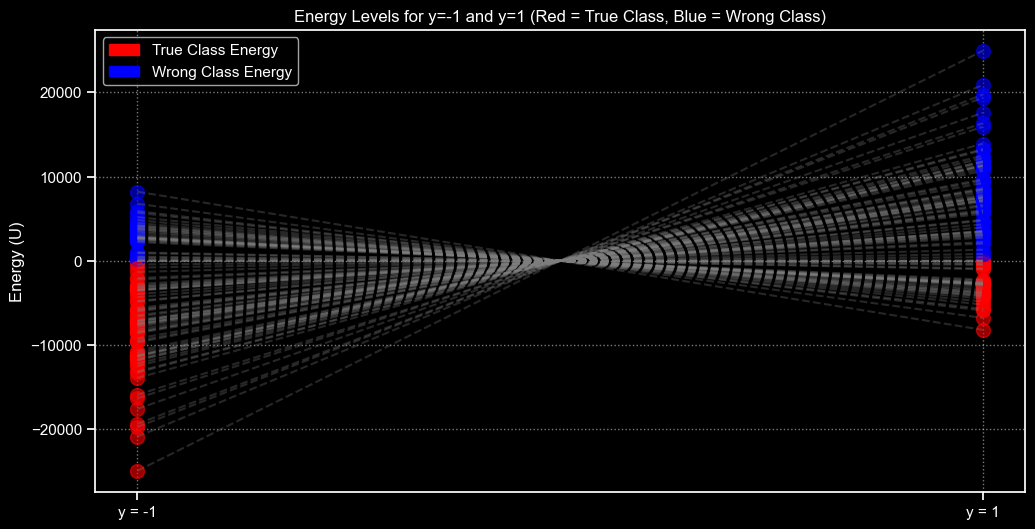

In [9]:
G = theta_opt_c[0] + np.dot(X_c_scaled, theta_opt_c[1:])

# energy if y = 1
U_y_1 = - (1) * G

# energy if y = -1
U_y_minus1 = - (-1) * G

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# We want x-axis to be the class label (-1 or 1)
# and y-axis to be the energy.
# Let's plot for the first 100 samples to keep the plot readable
samples_to_plot = 100

for i in range(samples_to_plot):
    # Plot energy for y=-1
    color_minus1 = 'red' if y_c_vals[i] == -1 else 'blue'
    plt.scatter(-1, U_y_minus1[i], color=color_minus1, alpha=0.6, s=100)
    
    # Plot energy for y=1
    color_1 = 'red' if y_c_vals[i] == 1 else 'blue'
    plt.scatter(1, U_y_1[i], color=color_1, alpha=0.6, s=100)
    
    # Draw a line connecting the two energy states for the same sample
    plt.plot([-1, 1], [U_y_minus1[i], U_y_1[i]], color='gray', linestyle='--', alpha=0.3)

plt.xticks([-1, 1], ['y = -1', 'y = 1'])
plt.ylabel('Energy (U)')
plt.title('Energy Levels for y=-1 and y=1 (Red = True Class, Blue = Wrong Class)')
plt.grid(True, linestyle=':', alpha=0.6)

# Create custom legend
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='True Class Energy')
blue_patch = mpatches.Patch(color='blue', label='Wrong Class Energy')
plt.legend(handles=[red_patch, blue_patch])

plt.show()


As you can see, most of the red dots are on the lower side of the plot, i.e. have lower energies that their corresponding blue dots. 

There are a few red dots whose energies are larger than the corresponding blue dots which are our misclassified samples. 

Let’s recap. 

To predict the tumor class of a row of the dataset, we inserted the values of all the columns that we specified as $X$ into the following energy function
$$
E_{\theta}(X, y) =  -y \,(\theta_0 + \theta_1 X_1 + \cdots \theta_k X_k)
$$

We also inserted the optimal values of the $\theta$ into the function. 

Next, we computed the energy once by substituting $y=1$ and another time by inserting $y=-1$. 

Then we compared the two energies and selected the y value that returned lower energies.

But there is a more efficient way to make the same prediction. 

Note that the lower energy will be achieved when $y$ has the same sign as $\theta_0 + \theta_1 X_1 + \cdots \theta_k X_k$. 

So our prediction will be the following equation
$$
\hat{y} = \text{Sign}(\theta_0 + \theta_1 X_1 + \cdots \theta_k X_k),
$$

which we have implemented in the following code and used it to <span style="color:red;"><strong>compute the accuracy of the model</strong></span>

In [10]:
# EBM Prediction logic: lowest energy occurs at target that matches the sign of G_X
y_c_pred = np.sign(G)

# Handle cases where G_X_pred could be exactly 0 (np.sign returns 0)
# We can map 0 to either 1 or -1; let's map it to 1
y_c_pred[y_c_pred == 0] = 1

# Calculate accuracy
accuracy = np.mean(y_c_pred == y_c_vals)

print(f"Classification Accuracy: {accuracy * 100:.2f}%")

Classification Accuracy: 100.00%


##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">Fully Connected Neural Network (FCNN) as EBM:</h2></div>

Let's now take a quick look at the energy landscape of an example FCNN that takes $x$ as input and returns $y$ as output and has one <span style="color:red;"><strong>hidden layer of 50 neurons</strong></span>. 

<div class="text-center" align="center">
<img src="Utils/FCNN.png?t=2" alt="FCNN Architecture" width="50%">
</div>


We assume $x$<span style="color:red;"><strong> and </strong></span>$y$<span style="color:red;"><strong> are continuous</strong></span> and therefore the <span style="color:red;"><strong>network is doing a regression</strong></span>, and the network is a function, of unknown analytical form, $f_\theta(x)$
$$
y = f_\theta(x)
$$

For any regression machine learning, we define the energy as the following

$$
E(\vec{x}, \vec{y}) = \frac{1}{2} ||f_\theta(\vec{x}) - \vec{y}||^2
$$


Let's now take a random dataset from sckikit-learn. We don't care what the dataset is about. For our purpose, <span style="color:red;"><strong>we just need a dataset to train this network to find </strong></span>$\theta$<span style="color:red;"><strong> parameters</strong></span> so that $f_\theta(x)$ does the right mapping. Then we will <span style="color:red;"><strong>create a grid of all </strong></span>$x$<span style="color:red;"><strong> and </strong></span>$y$<span style="color:red;"><strong> values</strong></span>, which are not the $x$ and $y$ of the dataset but instead "all" possible combinations of $x$ and $y$. We insert all $x$ into the network a<span style="color:red;"><strong>nd get networks output </strong></span>$f_\theta(x)$ then <span style="color:red;"><strong>insert</strong></span> the latter and all possible $y$ values <span style="color:red;"><strong>into the energy function</strong></span> and make a 3D plot


<div class="text-center" align="center">
<img src="Utils/FCNN_energy_3d.png?t=2" alt="FCNN Architecture" width="40%">
</div>


As you can see, <span style="color:red;"><strong>for every given </strong></span>$x$<span style="color:red;"><strong>, there is only one </strong></span>$y$<span style="color:red;"><strong> value whose corresponding energy is minimum</strong></span>, that will be <span style="color:red;"><strong>the prediction of our EBM model</strong></span>. 


But, prediction using a plot is not possible in practical neural nets with many input neurons because we cannot make a plot in more than 3 dimensions. So, the practical method to make a prediction is minimization of energy. But, this time we minimize with respect to the output variable $y$ and not the free parameters. 


So, let's do the minimization. 

First, we write the energy in component form:

$$
E(\vec{x}, \vec{y}) = \frac{1}{2}\sum_j \left(f_\theta(\vec{x})_j - y_j\right)^2
$$

Then we take the partial derivative with respect to a single component $y_i$. Note that only the $j = i$ term survives:

$$
\frac{\partial E}{\partial y_i} = \frac{1}{2} \cdot 2\left(f_\theta(\vec{x})_i - y_i\right) \cdot (-1) = y_i - f_\theta(\vec{x})_i
$$


Now we gather all components together to write this in vector form:

$$
\nabla_{\vec{y}} E(\vec{x}, \vec{y}) = \vec{y} - f_\theta(\vec{x})
$$

The minimum of energy is where this derivative is zero, which means our prediction for the output $\vec{y}$ is the following
$$
\vec{\hat{y}} = f_\theta(\vec{x})
$$

Note that the right hand side is just the output layer of the conventional neural network. In other words, the energy based model has the same prediction as the conventional neural network. 



###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ EBM model of FCNN for Multi-Class Classification</h3>

<div class="text-center" align="center">
<img src="Utils/FCNN_digits.png?t=1" alt="FCNN Digit Classifier Architecture" width="30%">
</div>

If you are using an FCNN for standard classification (where the last layer is a Softmax), the neural network outputs a vector of unnormalized scores, called logits. Let's <span style="color:red;"><strong>denote the network's output for input </strong></span>$x$<span style="color:red;"><strong> and class </strong></span>$y$<span style="color:red;"><strong> as </strong></span>$f_\theta(x,y)$.

In a probabilistic framework, the <span style="color:red;"><strong>Softmax function</strong></span> turns these logits into probabilities:

$$
P(y|x) = \frac{e^{f_\theta(x,y)}}{\sum_{c} e^{f_\theta(x,c)}}
$$

In the EBM framework, the probability is defined using the Boltzmann distribution, where probability is proportional to the negative exponent of the energy:

$$
P(y|x) = e^{-E(x, y)}/Z
$$

<span style="color:red;"><strong>By matching these two equations</strong></span>, we get the corresponding energy function for a classification FCNN:

$$
E(x, y) = -f_\theta(x,y)
$$

The <span style="color:red;"><strong>energy</strong></span> of a specific input-class pair $(x, y)$ is simply the <span style="color:red;"><strong>negative logit assigned to that class</strong></span> by the neural network. 

The network learns to push the energy down (push the logit up) for the correct class, and pull the energy up (push the logits down) for incorrect classes.


##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">EBMs as generative models</h2></div>


<span style="color:red;"><strong>Energy-Based Models (EBMs)</strong></span> have become an exciting tool <span style="color:red;"><strong>for generative modeling</strong></span>, and what makes them special is how naturally they connect to ideas straight out of statistical mechanics.

But, first let's specify what is a generative model at all. 

Suppose we have a dataset of samples $x_1, x_2, \dots, x_N$, which can be images, sentences, molecular configurations, etc., drawn from some unknown data distribution $p_{\text{data}}(x)$. 

<span style="color:red;"><strong>A generative model is a model that tries to learn this distribution of a dataset.</strong></span> 

Once we have a good approximation, we can <span style="color:red;"><strong>generate (sample) new data points</strong></span> that look like they came from the original dataset. That is the basis of how Google's nano banana or OpenAI's GPT-Image-2 work. 


<span style="color:red;"><strong>The central difficulty in all generative models is that </strong></span>$p_{\text{data}}(x)$<span style="color:red;"><strong> lives in an enormously high-dimensional space</strong></span>, and probability distributions must satisfy a strict constraint: they must be non-negative and integrate to one,

$$\int p_\theta(x)\, dx = 1.$$


Different families of <span style="color:red;"><strong>generative models handle this normalization constraint in different ways</strong></span>. I categorize them as those that try to somehow compute the integral and those that try to avoid it:

* Generative AI models that try to <span style="color:red;"><strong>compute the integral</strong></span>:
    * <span style="color:red;"><strong>Autoregressive models</strong></span> factorize the distribution into a product of conditionals, each of which is normalized by construction — so the full integral comes for free;
    * <span style="color:red;"><strong>VAEs</strong></span> optimize a variational bound, computing the integral only approximately by bounding it from below.
    * <span style="color:red;"><strong>Normalizing flows</strong></span> use invertible transformations with tractable Jacobians, giving an exact, computable density;

* Generative AI models that try to <span style="color:red;"><strong>avoid the integral</strong></span>:
    * <span style="color:red;"><strong>Diffusion models</strong></span> avoid the density entirely, learning only its score through a chain of Gaussian denoising steps;
    * <span style="color:red;"><strong>Energy-based models</strong></span> take arguably the most radical approach: they simply refuse to normalize.

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Generative EBMs Through an Example</h3>

Let's assume the <span style="color:red;"><strong>true distribution</strong></span> of a dataset has a Gaussian form with
* the mean of $\mu=0$, 
* variance of $\sigma^2=1$. 

Here we are <span style="color:red;"><strong>acting as God</strong></span>. Otherwise, for a real-world dataset, we never know the true distribution.

However, after using a s<span style="color:red;"><strong>tatistical inference method</strong></span> applied to the dataset we <span style="color:red;"><strong>find slightly different mean and variances</strong></span>. 

<span style="color:red;"><strong>For a Gaussian distribution, the energy function has the following form</strong></span>
$$
U_\theta(x) = \frac{(x - \mu)^2 }{ 2 \sigma^2}.
$$

To derive it, simply compare the probability distribution of a Gaussian distribution and that of an EBM. 

Let's first <span style="color:red;"><strong>plot these distributions</strong></span>

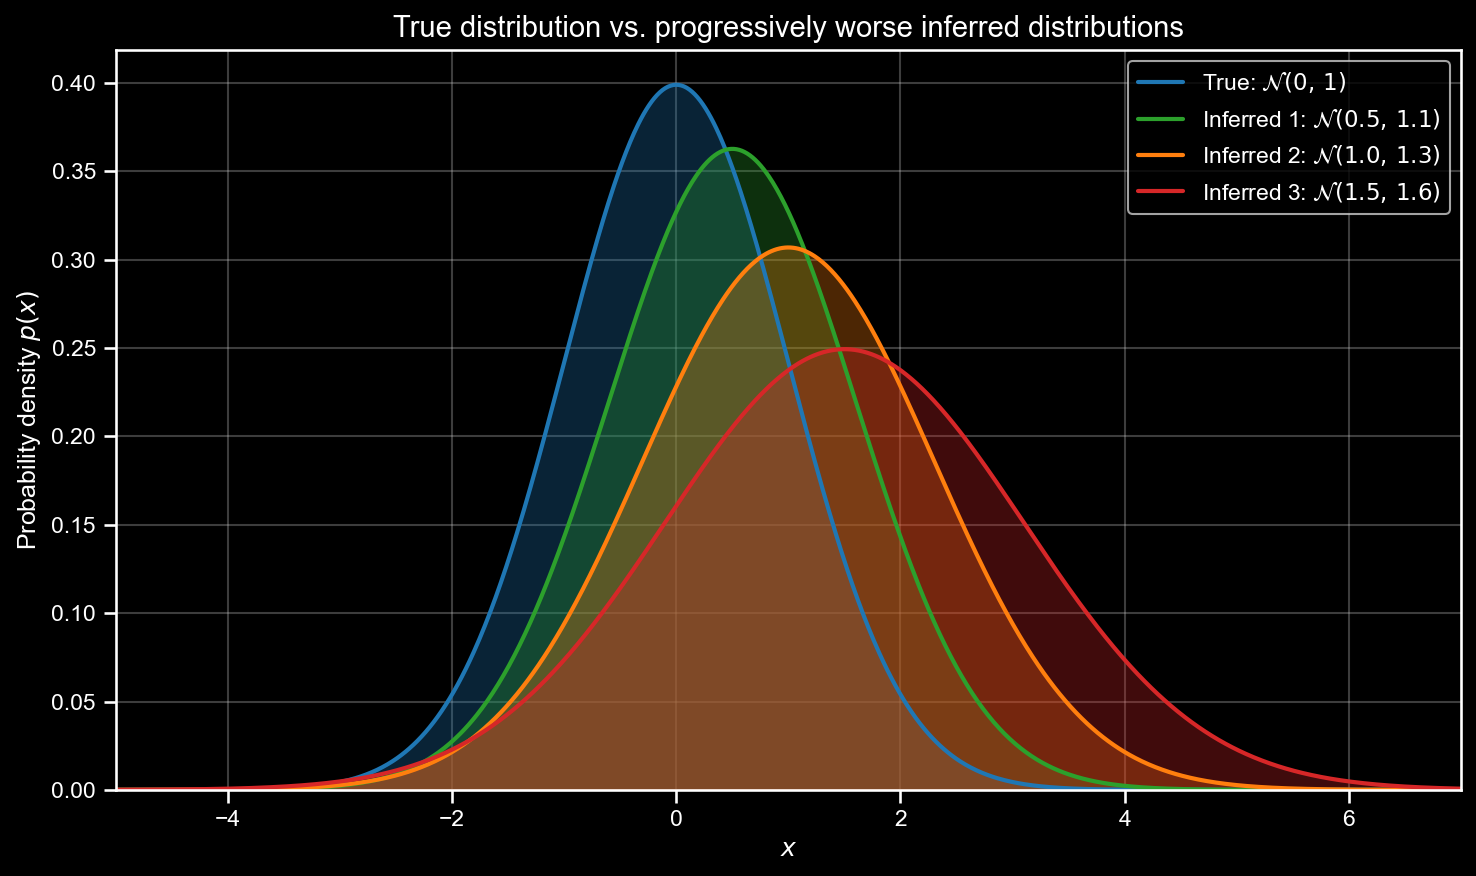

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ----- Define the distributions -----------------------------------------
# (label, mean, std, fill color)
distributions = [
    ("True: $\\mathcal{N}(0,\\,1)$",           0.0, 1.0, "#1f77b4"),
    ("Inferred 1: $\\mathcal{N}(0.5,\\,1.1)$", 0.5, 1.1, "#2ca02c"),
    ("Inferred 2: $\\mathcal{N}(1.0,\\,1.3)$", 1.0, 1.3, "#ff7f0e"),
    ("Inferred 3: $\\mathcal{N}(1.5,\\,1.6)$", 1.5, 1.6, "#d62728"),
]

x = np.linspace(-5, 7, 1000)

# ----- Plot ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

for label, mu, sigma, color in distributions:
    pdf = norm.pdf(x, loc=mu, scale=sigma)
    ax.plot(x, pdf, color=color, linewidth=2, label=label)
    ax.fill_between(x, pdf, alpha=0.30, color=color)

ax.set_title("True distribution vs. progressively worse inferred distributions",
             fontsize=14)
ax.set_xlabel("$x$", fontsize=12)
ax.set_ylabel("Probability density $p(x)$", fontsize=12)
ax.legend(fontsize=11, frameon=True)
ax.grid(alpha=0.3)
ax.set_xlim(-5, 7)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

To make <span style="color:red;"><strong>our model </strong></span>$\rho_{\theta}(x)$ match the <span style="color:red;"><strong>true data distribution </strong></span>$\rho_{*}(x)$, <span style="color:red;"><strong>we want to minimize the difference</strong></span> between them. This is typically done by <span style="color:red;"><strong>minimizing the cross-entropy</strong></span> between the true distribution and the model distribution.

$$
H(\rho_{*},\rho_{\theta}) = -\int_{\mathbb{R}^d} \rho_{*}(x)\,\log\rho_{\theta}(x)\,dx = \int_{\mathbb{R}^d} \rho_{*}(x)\, \left( U_{\theta}(x) + \log Z_{\theta} \right) \,dx = \mathbb{E}_{*}[U_{\theta}] + \log Z_{\theta}
$$

Let's now <span style="color:red;"><strong>compute cross entropy for each of the three inference methods</strong></span> in this plot

In [12]:
from scipy.stats import norm
from scipy.integrate import quad

# ----- True distribution --------------------------------------------------
mu_p, sigma_p = 0.0, 1.0

# ----- Inferred distributions (same as the earlier plot) -------------------
inferred = [
    ("Inferred 1", 0.5, 1.1, "#2ca02c"),
    ("Inferred 2", 1.0, 1.3, "#ff7f0e"),
    ("Inferred 3", 1.5, 1.6, "#d62728"),
]

def cross_entropy_numeric(mu_q, sigma_q):
    """H(p, q) = -int p(x) log q(x) dx, by numerical integration."""
    integrand = lambda x: -norm.pdf(x, mu_p, sigma_p) * norm.logpdf(x, mu_q, sigma_q)
    val, _ = quad(integrand, -np.inf, np.inf)
    return val


def expected_energy(mu_q, sigma_q):
    """E_*[U_theta] with U_theta(x) = (x - mu_q)^2 / (2 sigma_q^2)."""
    return (sigma_p**2 + (mu_p - mu_q)**2) / (2 * sigma_q**2)


# ----- Compute and report --------------------------------------------------
# Baseline: entropy of the true distribution, H(p, p) = the minimum possible.
H_self = cross_entropy_numeric(mu_p, sigma_p)
print(f"Cross Entropy of the true N(0,1) (lower bound): H(p, p) = {H_self:.4f}\n")

header = f"{'Distribution':<12} {'mu':>5} {'sigma':>6} {'E_*[U]':>8} {'log Z':>8} " \
         f"{'H':>12}"
print(header)
print("-" * len(header))

results = []
for name, mu_q, sigma_q, color in inferred:
    E_U = expected_energy(mu_q, sigma_q)
    logZ = np.log(sigma_q * np.sqrt(2 * np.pi))
    H_num = cross_entropy_numeric(mu_q, sigma_q)
    results.append((name, mu_q, sigma_q, color, H_num))
    print(f"{name:<12} {mu_q:>5.1f} {sigma_q:>6.1f} {E_U:>8.4f} {logZ:>8.4f} "
          f"{H_num:>11.4f}")

Cross Entropy of the true N(0,1) (lower bound): H(p, p) = 1.4189

Distribution    mu  sigma   E_*[U]    log Z            H
--------------------------------------------------------
Inferred 1     0.5    1.1   0.5165   1.0142      1.5308
Inferred 2     1.0    1.3   0.5917   1.1813      1.7730
Inferred 3     1.5    1.6   0.6348   1.3889      2.0237


To easily map the columns of this table, let's re-write the equation for cross-entropy once again:

$$
H(\rho_{*},\rho_{\theta}) = -\int_{\mathbb{R}^d} \rho_{*}(x)\,\log\rho_{\theta}(x)\,dx = \mathbb{E}_{*}[U_{\theta}] + \log Z_\theta
$$

Note that for the example above, the free parameters $\theta$<span style="color:red;"><strong> refers to </strong></span>$\mu$<span style="color:red;"><strong> and </strong></span>$\sigma$. As you can see from the table, the cross-entropy depends on the values of $\theta$. Since ideally we want our model distribution be closest to the true distribution, <span style="color:red;"><strong>we want to choose the values of </strong></span>$\theta$<span style="color:red;"><strong> such that cross entropy returns the minimum value</strong></span>. 

<span style="color:red;"><strong>Therefore, our loss function in generative EBMs is usually the cross-entropy.</strong></span>

To minimize corss-entropy, we take a <span style="color:red;"><strong>derivatives</strong></span> of it <span style="color:red;"><strong>with respect to </strong></span>$\theta$ (in the example above we take two derivatives. Once with respect to $\mu$ and another time with respect to $\sigma$) and <span style="color:red;"><strong>set that to zero</strong></span>. This will give us a set of equations which we can solve to find the optimal values of $\theta$. 

Let's now take the gradient of the loss function step by step. 

Since the true distribution is not a function of $\theta$, the derivative passes through the first expectation

$$
\partial_{\theta}H(\rho_{*},\rho_{\theta}) = \mathbb{E}_{*}[\partial_{\theta}U_{\theta}] + \partial_{\theta}\log Z_{\theta}
$$

and since $Z_{\theta} = \int e^{-U_{\theta}(x)}\, dx$ and $\rho_\theta = \frac{1}{Z_\theta} e^{-U_{\theta}}$, we get 

$$
\partial_{\theta}\log Z_{\theta} = \frac{\partial_{\theta} Z_{\theta}}{Z_{\theta}}= -\int \partial_{\theta}U_{\theta}\, \frac{1}{Z_\theta} e^{-U_{\theta}(x)}dx = -\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}],
$$
which yields the difference of two expectation values

$$
\partial_{\theta}H(\rho_{*},\rho_{\theta}) = 
\mathbb{E}_{*}[\partial_{\theta}U_{\theta}] 
- 
\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]
$$

<span style="color:red;"><strong>Computing the right hand side of this equation is the main task of training generative EBMs:</strong></span>

* The <span style="color:red;"><strong>first term</strong></span>, $\mathbb{E}_{*}[\partial_{\theta}U_{\theta}]$, is the expectation over the true data. <span style="color:red;"><strong>We can easily estimate this by averaging </strong></span>$\partial_{\theta}U_{\theta}$<span style="color:red;"><strong> over our training dataset.</strong></span>

* The <span style="color:red;"><strong>second term</strong></span>, $\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]$, is the expectation over our model's distribution. If data has a very high dimension, computing this term will become challenging since we need to know the normalization constant $Z_{\theta}$ and that <span style="color:red;"><strong>requires solving a very high-dimensional integral over the entire </strong></span>$\mathbb{R}^{d}$<span style="color:red;"><strong> space. In this case, standard numerical integration is practically impossible.</strong></span>

##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">Numerical Intuition Through an Example</h2></div>


Let's now make all of the above concrete with <span style="color:red;"><strong>a fully worked 1-D example</strong></span>. Recall that the gradient of our loss (the cross-entropy) is a difference of two expectation values:

$$
\partial_{\theta}H(\rho_{*},\rho_{\theta}) =
\underbrace{\mathbb{E}_{*}[\partial_{\theta}U_{\theta}]}_{\text{average over the data}}
-
\underbrace{\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]}_{\text{average over model samples}}
$$

<span style="color:red;"><strong>Our plan</strong></span> is:

1. <span style="color:red;"><strong>Generate a dataset</strong></span> of 1000 points from the true distribution $\mathcal{N}(0, 1)$. 
    - Note: In reality, we observe a system to collect this dataset. But since we know the true distribution, here we simply generate the dataset.
2. <span style="color:red;"><strong>Estimate the first expectation</strong></span> $\mathbb{E}_{*}[\partial_{\theta}U_{\theta}]$ by averaging over the dataset.
3. <span style="color:red;"><strong>Estimate the second expectation</strong></span> $\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]$ with a simple Monte Carlo method (averaging over samples drawn from the model).
4. Put the two together and <span style="color:red;"><strong>solve the system of equations </strong></span>$\partial_{\mu}H = 0$<span style="color:red;"><strong> and </strong></span>$\partial_{\sigma}H = 0$<span style="color:red;"><strong> to find the optimal </strong></span>$\mu$<span style="color:red;"><strong> and </strong></span>$\sigma$.


###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 1 — Generate the training dataset</h3>

We draw $N = 1000$ samples from the true distribution $\rho_{*} = \mathcal{N}(0, 1)$, and plot them as a histogram. 

The x-axis shows the single column of our dataset. The y-axis shows how often the corresponding x-value appears in the rows of the dataset. 

This histogram of samples is the only thing our "training algorithm" is allowed to see. <span style="color:red;"><strong>The training algorithm does not know the true </strong></span>$\mu$<span style="color:red;"><strong> and </strong></span>$\sigma$.

Let's first plot the <span style="color:red;"><strong>histogram of the generated 1-dimensional data</strong></span>.

Dataset size      : 1000
Sample mean       : -0.0289
Sample std        : 0.9887


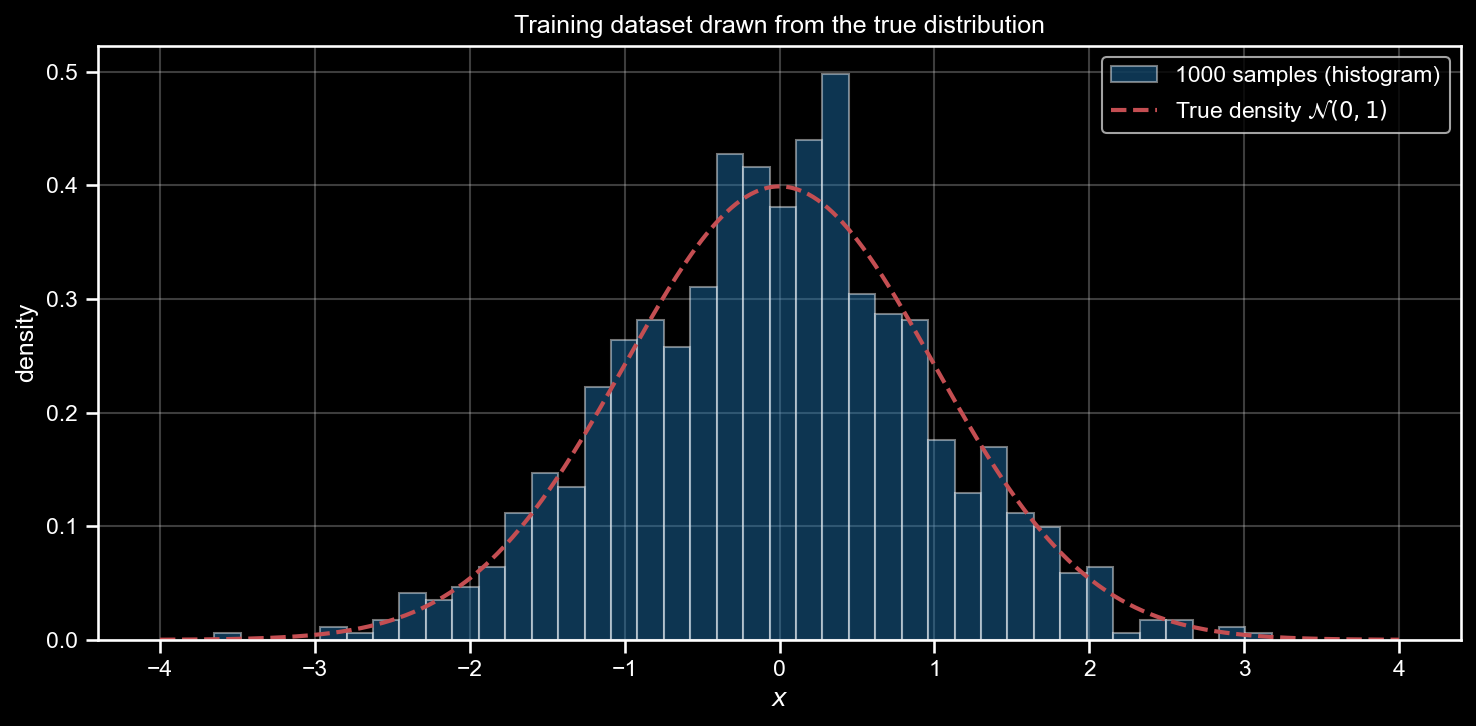

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(seed=42)

# ----- True (hidden) distribution and the dataset --------------------------
mu_true, sigma_true = 0.0, 1.0
N = 1000
data = rng.normal(loc=mu_true, scale=sigma_true, size=N)

print(f"Dataset size      : {data.size}")
print(f"Sample mean       : {data.mean():.4f}")
print(f"Sample std        : {data.std(ddof=0):.4f}")

# ----- Plot -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.hist(data, bins=40, density=True, alpha=0.45, color="#1f77b4",
        edgecolor="white", label="1000 samples (histogram)")
xg = np.linspace(-4, 4, 500)
ax.plot(xg, norm.pdf(xg, mu_true, sigma_true), "r--", lw=2,
        label="True density $\\mathcal{N}(0,1)$")
ax.set_xlabel("$x$"); ax.set_ylabel("density")
ax.set_title("Training dataset drawn from the true distribution")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Notice that the sample mean and standard deviation are *close to* but not *exactly* $0$ and $1$. With a finite dataset, this is the best any method can hope to recover.

### 
---
$\mathbb{E}_{*}[\partial_{\theta}U_{\theta}]$: 
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 2 — Data expectation of the gradients of the energy</h3> 



For the Gaussian energy $U_{\theta}(x) = \dfrac{(x-\mu)^2}{2\sigma^2}$ with parameters $\theta = (\mu, \sigma)$, the two components of $\partial_{\theta}U_{\theta}$ are

$$
\frac{\partial U_{\theta}}{\partial \mu} = -\frac{x-\mu}{\sigma^{2}},
\qquad
\frac{\partial U_{\theta}}{\partial \sigma} = -\frac{(x-\mu)^{2}}{\sigma^{3}}.
$$

The first expectation in the gradient of the cross-entropy is over the *true* distribution — and this is exactly what our dataset gives us for free:

$$
\mathbb{E}_{*}[\partial_{\theta}U_{\theta}] \;\approx\; \frac{1}{N}\sum_{i=1}^{N} \partial_{\theta}U_{\theta}(x_i),
\qquad x_i \sim \rho_{*}.
$$


At the beginning, before the training, we start with an <span style="color:red;"><strong>initial guess</strong></span> for the values of $\theta$. We set $\mu=2$<span style="color:red;"><strong> and </strong></span>$\sigma=2$.

In [14]:
def grad_U(x, mu, sigma):
    """Gradients of the energy U(x) = (x - mu)^2 / (2 sigma^2) w.r.t. mu and sigma."""
    dU_dmu    = -(x - mu) / sigma**2
    dU_dsigma = -(x - mu)**2 / sigma**3
    return dU_dmu, dU_dsigma


def data_expectation(mu, sigma, data):
    """First term: E_*[dU/dtheta], estimated as an average over the dataset."""
    g_mu, g_sigma = grad_U(data, mu, sigma)
    return g_mu.mean(), g_sigma.mean()


# Evaluate at a deliberately *wrong* initial guess theta_0 = (mu=2, sigma=2)
mu0, sigma0 = 2.0, 2.0
E_data = data_expectation(mu0, sigma0, data)
print(f"At (a deliberately *wrong* initial guess) theta = (mu={mu0}, sigma={sigma0}):")
print(f"  E_*[dU/dmu]    = {E_data[0]: .4f}")
print(f"  E_*[dU/dsigma] = {E_data[1]: .4f}")

At (a deliberately *wrong* initial guess) theta = (mu=2.0, sigma=2.0):
  E_*[dU/dmu]    =  0.5072
  E_*[dU/dsigma] = -0.6367


###
---
$\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]$:
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 3 — Monte Carlo estimate of the model expectation</h3>

The second expectation is over the *model's own* distribution $\rho_{\theta}$. <span style="color:red;"><strong>In general this is the hard part of training EBMs, because it requires sampling from </strong></span>$\rho_{\theta} = \frac{1}{Z_{\theta}}e^{-U_{\theta}}$<span style="color:red;"><strong> without knowing </strong></span>$Z_{\theta}$. <span style="color:red;"><strong>In our 1-D Gaussian toy model we are lucky: </strong></span>$\rho_{\theta}$<span style="color:red;"><strong> is just </strong></span>$\mathcal{N}(\mu, \sigma^2)$<span style="color:red;"><strong>, which we can sample directly</strong></span>. The Monte Carlo estimator is then a plain average over model samples:

$$
\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}] \;\approx\; \frac{1}{M}\sum_{j=1}^{M} \partial_{\theta}U_{\theta}(\tilde{x}_j),
\qquad \tilde{x}_j \sim \rho_{\theta}.
$$


So, let's <span style="color:red;"><strong>generate a sampled dataset</strong></span> using the model distribution again for the <span style="color:red;"><strong>same initial guess of </strong></span>$\mu=2$<span style="color:red;"><strong> and </strong></span>$\sigma=2$.
Next, we use the sampled dataset to compute the expectations of the derivatives.

Monte-Carlo estimate at the initial guess for theta = (mu=2.0, sigma=2.0):
  E_theta[dU/dmu]    =  0.0021   (exact: 0)
  E_theta[dU/dsigma] = -0.5058   (exact: -0.5000)


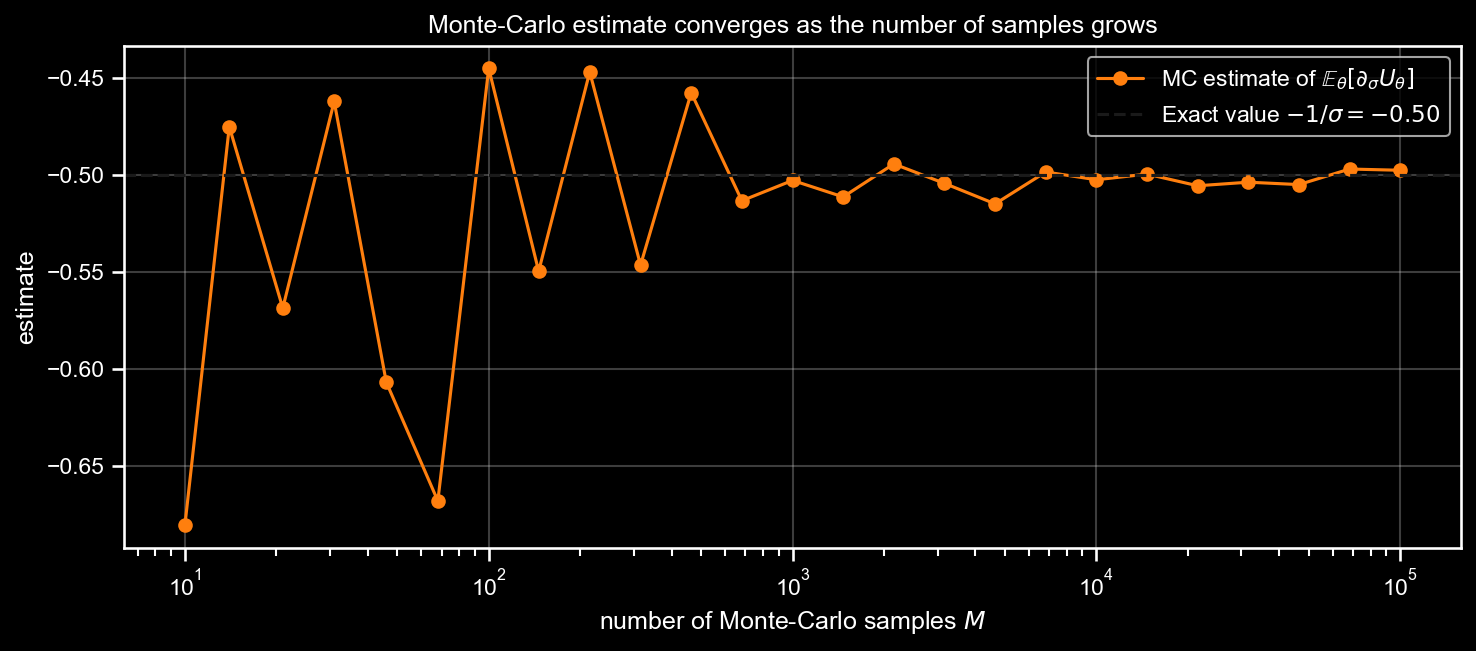

In [15]:
def model_expectation_mc(mu, sigma, n_samples=5000, rng=rng):
    """Second term: E_theta[dU/dtheta], estimated by Monte Carlo sampling
    from the model distribution rho_theta = N(mu, sigma^2)."""
    x_model = rng.normal(loc=mu, scale=sigma, size=n_samples)
    g_mu, g_sigma = grad_U(x_model, mu, sigma)
    return g_mu.mean(), g_sigma.mean()


E_model = model_expectation_mc(mu0, sigma0)
print(f"Monte-Carlo estimate at the initial guess for theta = (mu={mu0}, sigma={sigma0}):")
print(f"  E_theta[dU/dmu]    = {E_model[0]: .4f}   (exact: 0)")
print(f"  E_theta[dU/dsigma] = {E_model[1]: .4f}   (exact: {-1/sigma0:.4f})")

# ----- How fast does the Monte Carlo estimate converge? ---------------------
sample_sizes   = np.logspace(1, 5, 25).astype(int)
est_sigma_grad = [model_expectation_mc(mu0, sigma0, n)[1] for n in sample_sizes]

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.semilogx(sample_sizes, est_sigma_grad, "o-", color="#ff7f0e",
            label="MC estimate of $\\mathbb{E}_\\theta[\\partial_\\sigma U_\\theta]$")
ax.axhline(-1/sigma0, color="k", ls="--",
           label=f"Exact value $-1/\\sigma = {-1/sigma0:.2f}$")
ax.set_xlabel("number of Monte-Carlo samples $M$")
ax.set_ylabel("estimate")
ax.set_title("Monte-Carlo estimate converges as the number of samples grows")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The estimator is noisy for small $M$ but settles onto the exact value as $M$ grows — the usual $\mathcal{O}(1/\sqrt{M})$ behaviour of Monte Carlo.

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 4 — Put the two expectations together and solve for the optimal parameters</h3>

We now have numerical access to both terms, so we can assemble the full gradient of the loss function for any given $\theta$ parameter

$$
\partial_{\theta}H = \mathbb{E}_{*}[\partial_{\theta}U_{\theta}] - \mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]
$$

Our goal is to find the <span style="color:red;"><strong>optimal parameters </strong></span>$\theta = (\mu, \sigma)$<span style="color:red;"><strong> that minimize </strong></span>$H$ using the gradient descent method:

$$
\mu \leftarrow \mu - \eta\, \partial_{\mu}H,
\qquad
\sigma \leftarrow \sigma - \eta\, \partial_{\sigma}H.
$$

When the two expectations balance each other, the gradient vanishes and we have reached the solution of the system. We start from the deliberately bad initial guess $(\mu, \sigma) = (2, 2)$.

After 300 steps of gradient descent:
  mu_hat    = -0.0290   (sample mean = -0.0289)
  sigma_hat = 0.9850   (sample std  = 0.9887)


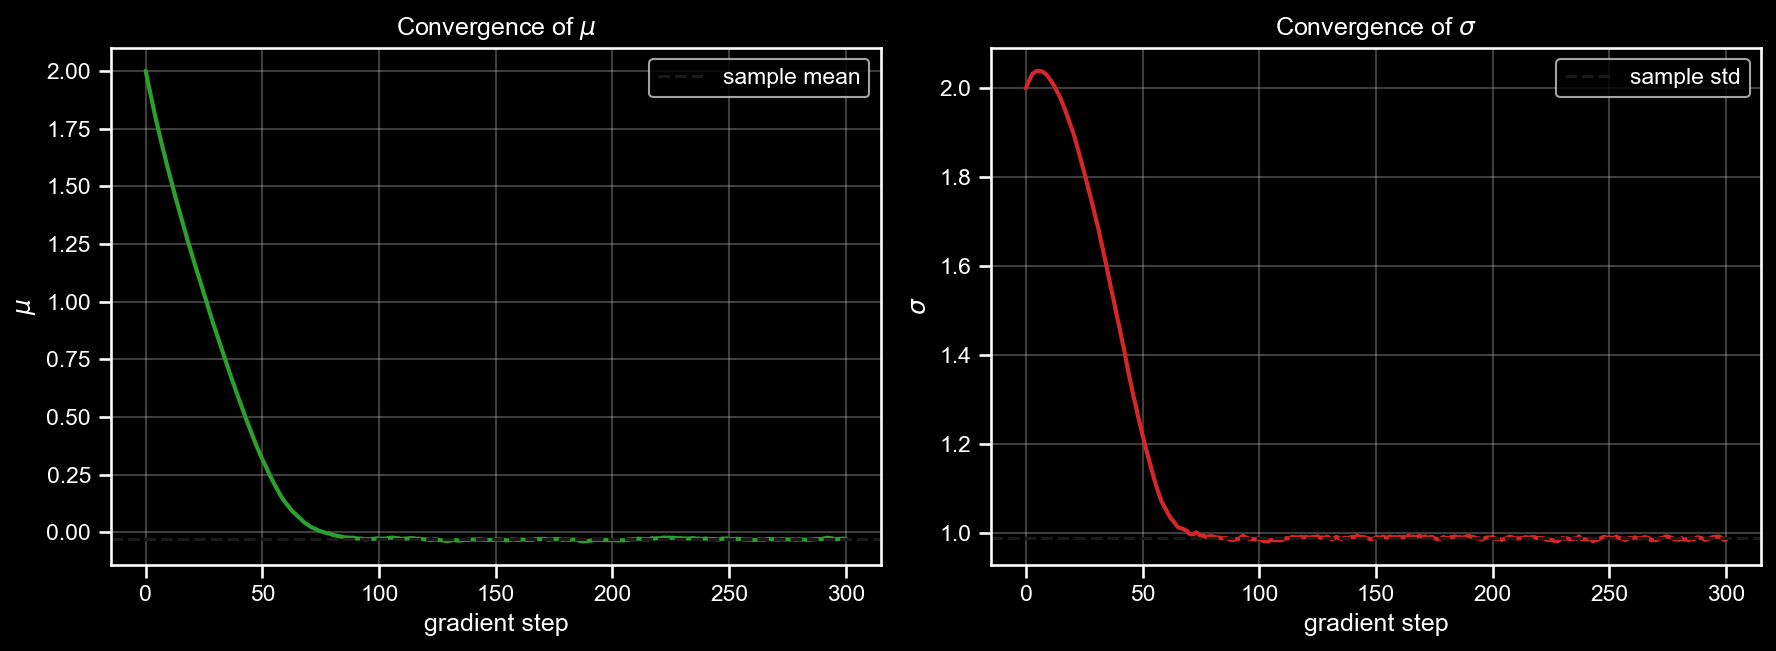

In [16]:
# ----- Gradient descent on the cross-entropy --------------------------------
mu_hat, sigma_hat = 2.0, 2.0          # bad initial guess
lr      = 0.1                          # learning rate eta
n_steps = 300
n_mc    = 5000                         # Monte-Carlo samples per step

traj = np.zeros((n_steps + 1, 2))
traj[0] = mu_hat, sigma_hat

for t in range(n_steps):
    g_data  = data_expectation(mu_hat, sigma_hat, data)       # E_*  [dU]
    g_model = model_expectation_mc(mu_hat, sigma_hat, n_mc)   # E_th [dU]

    grad_mu    = g_data[0] - g_model[0]    # dH/dmu
    grad_sigma = g_data[1] - g_model[1]    # dH/dsigma

    mu_hat    -= lr * grad_mu
    sigma_hat -= lr * grad_sigma
    traj[t + 1] = mu_hat, sigma_hat

print(f"After {n_steps} steps of gradient descent:")
print(f"  mu_hat    = {mu_hat:.4f}   (sample mean = {data.mean():.4f})")
print(f"  sigma_hat = {sigma_hat:.4f}   (sample std  = {data.std(ddof=0):.4f})")

# ----- Plot the trajectories -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)

axes[0].plot(traj[:, 0], color="#2ca02c", lw=2)
axes[0].axhline(data.mean(), color="k", ls="--", label="sample mean")
axes[0].set_xlabel("gradient step"); axes[0].set_ylabel("$\\mu$")
axes[0].set_title("Convergence of $\\mu$")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(traj[:, 1], color="#d62728", lw=2)
axes[1].axhline(data.std(ddof=0), color="k", ls="--", label="sample std")
axes[1].set_xlabel("gradient step"); axes[1].set_ylabel("$\\sigma$")
axes[1].set_title("Convergence of $\\sigma$")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Both parameters glide from the bad initial guess toward the statistics of the dataset. The small residual wiggle around the dashed lines is Monte-Carlo noise from the finite number of model samples per step.

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Cross-check: solving the system of equations analytically</h3>

For this simple model, and since we are acting as God and know the true distribution, we can also solve $\partial_{\theta}H = 0$ and find optimal $\theta$ with pen and paper, which tells us exactly where gradient descent *should* land. Setting each component of the gradient to zero:
$$
\mathbb{E}_{*}[\partial_{\theta}U_{\theta}] - \mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]
$$
<span style="color:red;"><strong>Equation for </strong></span>$\mu$<span style="color:red;"><strong>:</strong></span>

$$
\mathbb{E}_{*}\!\left[-\frac{x-\mu}{\sigma^{2}}\right] - \mathbb{E}_{\theta}\!\left[-\frac{x-\mu}{\sigma^{2}}\right] = 0
\;\;\Longrightarrow\;\;
\mathbb{E}_{*}[x] = \mathbb{E}_{\theta}[x] = \mu
\;\;\Longrightarrow\;\;
\mu^{\star} = \frac{1}{N}\sum_{i} x_i
$$

<span style="color:red;"><strong>Equation for </strong></span>$\sigma$<span style="color:red;"><strong>:</strong></span>

$$
\mathbb{E}_{*}\!\left[-\frac{(x-\mu)^{2}}{\sigma^{3}}\right] - \mathbb{E}_{\theta}\!\left[-\frac{(x-\mu)^{2}}{\sigma^{3}}\right] = 0
$$

Multiply both sides by $\sigma^3$:

$$
\mathbb{E}_{*}[(x-\mu)^{2}] = \mathbb{E}_{\theta}[(x-\mu)^{2}] = \sigma^{2}
\;\;\Longrightarrow\;\;
\sigma^{\star^{2}} = \frac{1}{N}\sum_{i} (x_i - \mu^{\star})^{2}
$$

In words: the optimum is reached exactly when <span style="color:red;"><strong>the model's moments match the data's moments</strong></span> — the sample mean and the sample standard deviation. (These are the familiar maximum-likelihood estimators, which makes sense: minimizing cross-entropy is equivalent to maximizing the likelihood of the data.)

Let's now <span style="color:red;"><strong>plot the dataset</strong></span> (that we generated from the true distribution) together with the <span style="color:red;"><strong>learned distribution</strong></span> and our <span style="color:red;"><strong>initially guessed</strong></span> distribution

                              mu     sigma
True parameters           0.0000    1.0000
Closed-form solution     -0.0289    0.9887
Gradient descent         -0.0290    0.9850


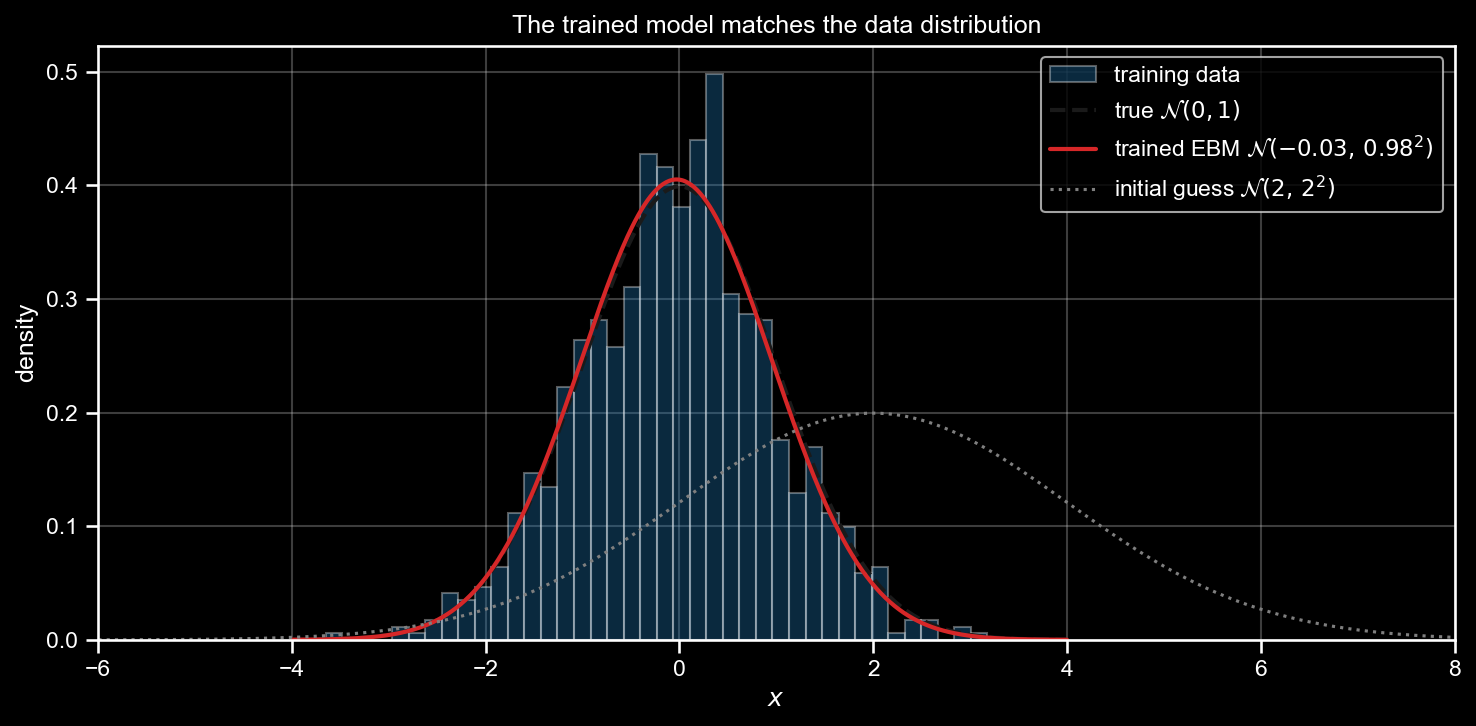

In [17]:
# ----- Closed-form solution of the system ------------------------------------
mu_star    = data.mean()
sigma_star = data.std(ddof=0)

print(f"{'':<22}{'mu':>10}{'sigma':>10}")
print(f"{'True parameters':<22}{mu_true:>10.4f}{sigma_true:>10.4f}")
print(f"{'Closed-form solution':<22}{mu_star:>10.4f}{sigma_star:>10.4f}")
print(f"{'Gradient descent':<22}{mu_hat:>10.4f}{sigma_hat:>10.4f}")

# ----- Final comparison plot --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.hist(data, bins=40, density=True, alpha=0.35, color="#1f77b4",
        edgecolor="white", label="training data")
ax.plot(xg, norm.pdf(xg, mu_true, sigma_true), "k--", lw=2,
        label="true $\\mathcal{N}(0,1)$")
ax.plot(xg, norm.pdf(xg, mu_hat, sigma_hat), color="#d62728", lw=2,
        label=f"trained EBM $\\mathcal{{N}}({mu_hat:.2f},\\,{sigma_hat:.2f}^2)$")
x0 = np.linspace(-8, 8, 500)
ax.plot(x0, norm.pdf(x0, 2.0, 2.0), color="#7f7f7f", lw=1.5, ls=":",
        label="initial guess $\\mathcal{N}(2,\\,2^2)$")
ax.set_xlim(-6, 8)
ax.set_xlabel("$x$"); ax.set_ylabel("density")
ax.set_title("The trained model matches the data distribution")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">Analytical Intuition (The God View)</h2></div>

Now that we are done with the practical method of learning the free parameters of our model using a given dataset, let's build the analytical intuition as well. 

I call this the God view because, unlike the method that we just discussed, this is only possible if we were God and knew the true distribution of a dataset.

Let's remind ourselves that the energy function in 1D Gaussian distribution is
$$
U_\theta(x)   = \frac{(x - \mu)^2}{2 \sigma^2}
$$
and the normalization constant has the following form
$$
Z = (2 \pi \sigma^2)^{\frac{1}{2}}
$$

So, it is quite easy to take derivatives of the energy function with respect to the free parameters
$$
\partial_\mu U = - \frac{(x - \mu)}{\sigma^2}
$$
and
$$
\partial_\sigma U = -\frac{(x - \mu)^2}{\sigma^3}
$$

So, to find the optimal values for the free parameters, we need to solve the following system of equations

$$
\partial_\mu H = \mathbb{E}_{*}[\partial_{\mu}U] - \mathbb{E}_{\theta}[\partial_{\mu}U] = 0
$$
and 
$$
\partial_\sigma H = \mathbb{E}_{*}[\partial_{\sigma}U] - \mathbb{E}_{\theta}[\partial_{\sigma}U] = 0
$$

In 1-dimension, it is easy to calculate the integrals of the expectations analytically. This will give us a deep intuition. So, let's do these 


Note that for this example we assumed that the true distribution has a Gaussian form with the mean of $\mu_* = 0$ and variance of $\sigma_*^2=1$ <span style="color:red;"><strong>(acting as God)</strong></span>
$$
\rho_*(x) = \frac{1}{\sqrt{2\pi\sigma_*^2}}\, e^{-\frac{(x-\mu_*)^2}{2\sigma_*^2}} = \frac{1}{\sqrt{2\pi}}\, e^{-\frac{x^2}{2}}
$$

However, we want to forget the ground truth about $\rho_*$ (no longer act as God) and act as Human and model our data using a Gaussian distribution. That is the best a Human can do. But now the mean and variance are unknown to be determined by minimizing the cross entropy
$$
\rho_\theta(x) = \frac{1}{\sqrt{2\pi\sigma^2}}\, e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$


<span style="color:red;"><strong>Gradient with respect to </strong></span>$\mu$<span style="color:red;"><strong>:</strong></span>

The data-side expectation:
$$
\mathbb{E}_{*}[\partial_{\mu}U] 
= \int_{\mathbb{R}} \rho_*(x)\,\partial_{\mu}U(x)\,dx
= -\frac{1}{\sigma^2}\int_{\mathbb{R}} \rho_*(x)\,(x-\mu)\,dx
= -\frac{\mathbb{E}_*[x]-\mu}{\sigma^2}
= -\frac{\mu_* - \mu}{\sigma^2}
$$

and 
$$
\mathbb{E}_{\theta}[\partial_{\mu}U] 
= \int_{\mathbb{R}} \rho_\theta(x)\,\partial_{\mu}U(x)\,dx
= -\frac{1}{\sigma^2}\int_{\mathbb{R}} \rho_\theta(x)\,(x-\mu)\,dx
= -\frac{\mathbb{E}_\theta[x]-\mu}{\sigma^2}
= 0
$$
since $\mathbb{E}_\theta[x] = \mu$.

Together:
$$
\partial_\mu H = \mathbb{E}_{*}[\partial_{\mu}U] - \mathbb{E}_{\theta}[\partial_{\mu}U] 
= -\frac{\mu_* - \mu}{\sigma^2} - 0 
= \frac{\mu - \mu_*}{\sigma^2}
$$


<span style="color:red;"><strong>Gradient with respect to </strong></span>$\sigma$<span style="color:red;"><strong>:</strong></span>

The data-side expectation requires the second moment of $(x-\mu)$ under $\rho_*$. Writing $x-\mu = (x-\mu_*) + (\mu_*-\mu)$ and noting the cross term integrates to zero:
$$
\mathbb{E}_{*}[\partial_{\sigma}U] 
= \int_{\mathbb{R}} \rho_*(x)\,\partial_{\sigma}U(x)\,dx
= -\frac{1}{\sigma^3}\int_{\mathbb{R}} \rho_*(x)\,(x-\mu)^2\,dx
= -\frac{\sigma_*^2 + (\mu_* - \mu)^2}{\sigma^3}
$$

The model-side expectation uses $\int \rho_\theta(x)(x-\mu)^2\,dx = \sigma^2$, the variance of the model itself:
$$
\mathbb{E}_{\theta}[\partial_{\sigma}U] 
= \int_{\mathbb{R}} \rho_\theta(x)\,\partial_{\sigma}U(x)\,dx
= -\frac{1}{\sigma^3}\int_{\mathbb{R}} \rho_\theta(x)\,(x-\mu)^2\,dx
= -\frac{\sigma^2}{\sigma^3}
= -\frac{1}{\sigma}
$$

Together:
$$
\partial_\sigma H = \mathbb{E}_{*}[\partial_{\sigma}U] - \mathbb{E}_{\theta}[\partial_{\sigma}U] 
= -\frac{\sigma_*^2 + (\mu_* - \mu)^2}{\sigma^3} + \frac{1}{\sigma}
= \frac{1}{\sigma} - \frac{\sigma_*^2 + (\mu_* - \mu)^2}{\sigma^3}
$$


Now that we have the derivatives of $H$, we set both to zero and solve the system of equations

<span style="color:red;"><strong>Setting </strong></span>$\partial_\mu H = 0$:
$$
\frac{\mu - \mu_*}{\sigma^2} = 0 
\quad\Longrightarrow\quad 
\mu = \mu_*
$$

Setting $\partial_\sigma H = 0$ and multiplying through by $\sigma^3$:
$$
\frac{1}{\sigma} - \frac{\sigma_*^2 + (\mu_* - \mu)^2}{\sigma^3} = 0
\quad\Longrightarrow\quad
\sigma^2 = \sigma_*^2 + (\mu_* - \mu)^2
$$

Substituting the first result $\mu = \mu_*$ into the second kills the $(\mu_* - \mu)^2$ term:
$$
\sigma^2 = \sigma_*^2
\quad\Longrightarrow\quad
\sigma = \sigma_*
$$

so the unique stationary point of the cross entropy is
$$
\mu = \mu_*
$$
and 
$$
\sigma = \sigma_*
$$

i.e. <span style="color:red;"><strong>gradient descent on </strong></span>$H(\rho_*, \rho_\theta)$<span style="color:red;"><strong> recovers the true distribution exactly.</strong></span> 

Note that in this example we acted as both God and Human. But, in reality we can only act as a Human. That means we don't even know the form of true distribution to exactly calculate the first term in this equation

$$
\partial_\mu H = \mathbb{E}_{*}[\partial_{\mu}U] - \mathbb{E}_{\theta}[\partial_{\mu}U] 
$$
The practical method to estimate the expectation using the true distribution is to compute the term for each row of dataset
$$
\mathbb{E}_{*}[\partial_{\theta}U_{\theta}(x)] \simeq \frac{1}{N} \sum_{i=1}^N \partial_{\theta}U_{\theta}(x^{(i)})
$$
which is a function $\theta$. 

The second term is the expectation over our model's distribution
$$
\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}] = \int_{\mathbb{R}^d} dx\, \frac{1}{Z_\theta} e^{-U_\theta(x)} \, \partial_{\theta}U_{\theta}
$$ 
and the normalization constant itself is
$$
Z_\theta = \int_{\mathbb{R}^d} dx\, e^{-U_\theta(x)}
$$

If data has a very high dimension, i.e. $d \gg 1$ , computing this term will become challenging since we need to know the normalization constant $Z_{\theta}$ and that requires solving a very high-dimensional integral over the entire $\mathbb{R}^{d}$ space. In this case, standard numerical integration is practically impossible. So, we need to use numerical methods for training.

##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">High Dimensional Use Case</h2></div>

So far our toy example lived in one dimension, where we could compute every integral either analytically or by direct Monte Carlo. Now let's go to the opposite extreme. 

Assume we have a collection of <span style="color:red;"><strong>images</strong></span> that we want to use <span style="color:red;"><strong>as our dataset</strong></span>. 

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Overview</h3>

We will use the classic <span style="color:red;"><strong>MNIST dataset of handwritten digits</strong></span>. Each image is $28 \times 28 = 784$<span style="color:red;"><strong> pixels</strong></span>, so each "row of the dataset" (each configuration of the system) is a vector

$$
x \in \mathbb{R}^{784}.
$$

There is absolutely no hope of computing

$$
Z_\theta = \int_{\mathbb{R}^{784}} dx\, e^{-U_\theta(x)}
$$

by numerical integration. Even a laughably coarse grid with just 10 points per dimension would require $10^{784}$ evaluations, which is more than the number of atoms in the observable universe raised to roughly the 9th power.

So this is exactly the regime where the sampling-based training method from the previous section becomes one of our best options. 

Before getting deeper in each step and explain them, let me first briefly enumerate <span style="color:red;"><strong>all the steps that we need to take</strong></span> 

1. The <span style="color:red;"><strong>energy function </strong></span>$U_\theta(x)$<span style="color:red;"><strong> will be a neural network</strong></span> that takes an image as the input and returns a single scalar representing $U_\theta(x)$.

2. The data-side expectation $\mathbb{E}_{*}[\partial_\theta U_\theta]$ is estimated by averaging over mini-batches of real MNIST images.

3. The model-side expectation $\mathbb{E}_{\theta}[\partial_\theta U_\theta]$ is estimated by averaging over samples generated with the <span style="color:red;"><strong>Unadjusted Langevin Algorithm (ULA)</strong></span>, initialized from a persistent replay buffer of past samples (<span style="color:red;"><strong>Persistent Contrastive Divergence</strong></span>), with a small fraction of chains restarted from pure noise at every iteration.

4. The parameters follow the gradient of the cross-entropy:

$$
\partial_{\theta}H(\rho_{*},\rho_{\theta}) =
\mathbb{E}_{*}[\partial_{\theta}U_{\theta}]
-
\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]
$$

Intuitively, <span style="color:red;"><strong>training</strong></span> will <span style="color:red;"><strong>push the energy down on real images</strong></span> and <span style="color:red;"><strong>push the energy up on the images that are not like those in the training set</strong></span>, until the two sides balance and the gradient vanishes.

Let's build this step by step.

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 1 — Load MNIST and look at the data</h3>

We normalize pixel values to the range $[-1, 1]$. This matters for Langevin dynamics: the sampler will move randomly around in pixel space, and it is convenient to keep the "physical" region of configurations centered at zero.

In [21]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
DIGIT        = 8        # which digit to train on
BATCH_SIZE   = 128
N_EPOCHS     = 15
LR           = 1e-4
ALPHA        = 0.1      # energy-magnitude regularizer
BUFFER_SIZE  = 8192
REINIT_FRAC  = 0.05     # fraction of chains restarted from pure noise
LANGEVIN_STEPS_TRAIN = 60
LANGEVIN_STEPS_GEN   = 2000
STEP_SIZE    = 10.0
NOISE_STD    = 0.005
GRAD_CLIP    = 0.03
SEED         = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------------------------------------------------------
# Step 1 — Data
# ---------------------------------------------------------------------------
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,)),   # map pixels from [0,1] to [-1,1]
])

train_set = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

# # Keep only images of the chosen digit
# idx = (train_set.targets == DIGIT).nonzero(as_tuple=True)[0]
# train_set = torch.utils.data.Subset(train_set, idx)

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

print(f"Number of training images (digit {DIGIT}):", len(train_set))
print("Shape of one image:", train_set[0][0].shape)


Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.06MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]

Number of training images (digit 8): 60000
Shape of one image: torch.Size([1, 28, 28])


Let's <span style="color:red;"><strong>look at a few images</strong></span> (configurations) of our "system":

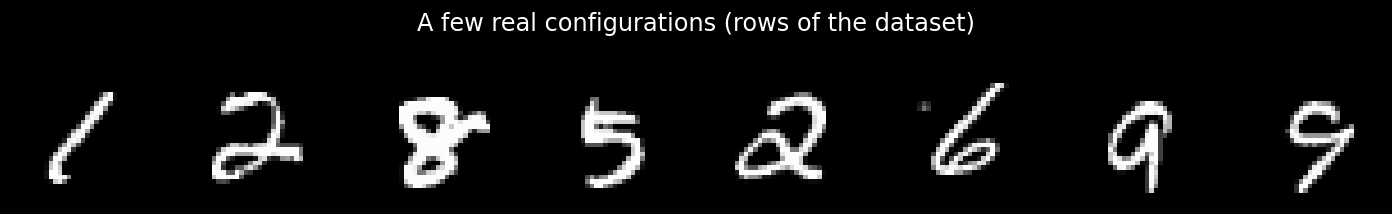

In [22]:
def show_images(imgs, title, n=8):
    """Plot a row of images (tensors in [-1, 1])."""
    imgs = imgs.detach().cpu()
    n = min(n, imgs.shape[0])
    fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 1.8), dpi=120)
    for i, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(imgs[i, 0] * 0.5 + 0.5, cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


x_batch, _ = next(iter(train_loader))
show_images(x_batch, "A few real configurations (rows of the dataset)")


Each of these images is one low-energy configuration of the system, in exactly the same sense that a snapshot of the gas container at the beginning of this lecture was one configuration of that system.

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 2 — The energy function is now a neural network</h3>



In the 1D toy model the energy had the fixed analytical form $U_\theta(x) = (x-\mu)^2 / 2\sigma^2$ with only two free parameters. For images we let a small convolutional network be the energy function:

$$
U_\theta : \mathbb{R}^{784} \longrightarrow \mathbb{R}
$$

Any network that maps an image to a single scalar is a legal energy function. This is the "significantly more freedom" we bought by throwing out $Z_\theta$.

One practical detail: we use smooth activations (SiLU/Swish) instead of ReLU. The reason is that as we discuss it below, the Langevin sampler needs $\nabla_x U_\theta(x)$, and a smooth energy landscape gives much better-behaved gradients than a piecewise-linear one.

Let's <span style="color:red;"><strong>implement this energy function in PyTorch</strong></span>:

In [23]:
class EnergyNet(nn.Module):
    """A small CNN that assigns a scalar energy to a 28x28 image."""
    def __init__(self, n_hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, n_hidden, 3, stride=2, padding=1),              # 28 -> 14
            nn.SiLU(),
            nn.Conv2d(n_hidden, 2 * n_hidden, 3, stride=2, padding=1),   # 14 -> 7
            nn.SiLU(),
            nn.Conv2d(2 * n_hidden, 2 * n_hidden, 3, stride=2, padding=1),  # 7 -> 4
            nn.SiLU(),
            nn.Flatten(),
            nn.Linear(2 * n_hidden * 4 * 4, 128),
            nn.SiLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        # Returns U_theta(x), one scalar per image in the batch
        return self.net(x).squeeze(-1)


model = EnergyNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Energy network has {n_params:,} free parameters (our theta).")


Energy network has 187,073 free parameters (our theta).


Before any training, the network knows nothing, and real digits and pure noise have statistically indistinguishable energies. 

In the following, we will verify this:

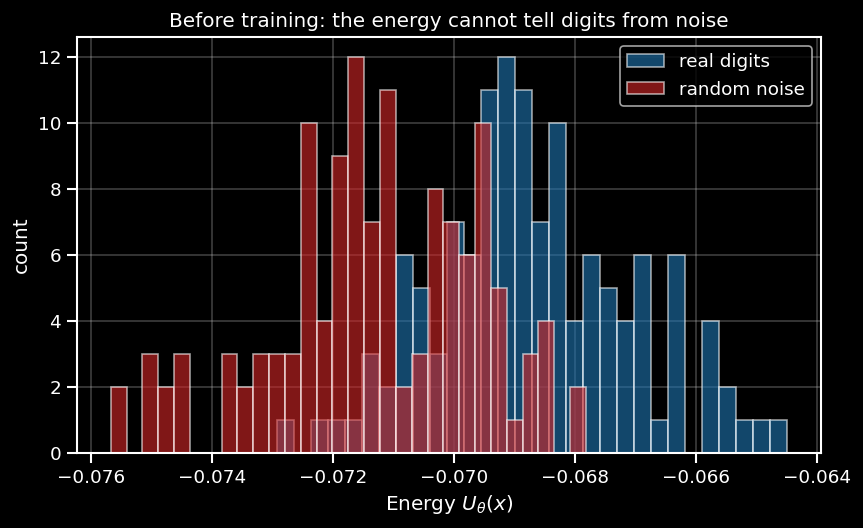

In [24]:
# ---------------------------------------------------------------------------
# Sanity check before training: digits vs noise should be indistinguishable
# ---------------------------------------------------------------------------
x_real, _ = next(iter(train_loader))
x_real = x_real.to(device)
x_noise = torch.rand_like(x_real) * 2 - 1 ## *2 -1 is to map [0, 1] -> [-1, 1]

with torch.no_grad():
    U_real_before  = model(x_real).cpu().numpy()
    U_noise_before = model(x_noise).cpu().numpy()

plt.figure(figsize=(8, 4.5), dpi=120)
plt.hist(U_real_before,  bins=30, alpha=0.6, label="real digits",  color="#1f77b4")
plt.hist(U_noise_before, bins=30, alpha=0.6, label="random noise", color="#d62728")
plt.xlabel("Energy $U_\\theta(x)$")
plt.ylabel("count")
plt.title("Before training: the energy cannot tell digits from noise")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

The two histograms overlap fairly well. <span style="color:red;"><strong>The entire goal of training the EBM is to separate them</strong></span>: real digits must sink to low energy, everything else must be pushed up to the hills of the energy landscape.

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 3 — The Langevin sampler (ULA)</h3>

<div class="text-center" align="center">
<img src="Utils/langevin_diffusion.gif" alt="diffusion" width="50%">
</div>

To estimate the model-side expectation $\mathbb{E}_{\theta}[\partial_\theta U_\theta]$ we need samples from $\rho_\theta(x) = e^{-U_\theta(x)}/ Z_\theta$.


Since in our extremely high dimensional space we cannot compute $Z_{\theta}$ analytically, we can estimate the second expectation using Monte Carlo sampling. This requires us to draw samples from the model's distribution $\rho_{\theta}(x)$ without actually knowing $Z_{\theta}$.

To achieve this, we use <span style="color:red;"><strong>Markov Chain Monte Carlo</strong></span> (MCMC) methods. 
A particularly popular method for when $x$ is continuous is the <span style="color:red;"><strong>Unadjusted Langevin Algorithm (ULA)</strong></span>. 


<span style="color:red;"><strong>Let me first explain how to use the ULA method then I will explain the derivation of ULA from physics principles.</strong></span>

<span style="color:red;"><strong>Here is the recipe.</strong></span> 

We <span style="color:red;"><strong>start from a randomly selected data point</strong></span> in the pixel space (an image with random pixel values).

That will be labeled as $x_0$. Here the index refers to time-step, as well as a row of the sampled dataset that we want to generate to estimate the expectation value.

We <span style="color:red;"><strong>generate the next sample</strong></span> using the following rule, 

$$
x_{k+1} = x_{k} - h\, \nabla U_{\theta_{k}}(x_k) + \sqrt{2h}\, \xi_{k},
$$

where $h$ is a step size that we set ourselves, and $\xi_{k} \sim \mathcal{N}(0_{d},I_{d})$ is an independent Gaussian noise.


To find the first generated sample, $x_1$, we insert $x_0$ into the right hand side of equation above. 

After $x_1$ is generated, we insert it into the right hand side of the same equation and the left hand side generates $x_2$. 

And <span style="color:red;"><strong>we repeat this loop for as many times as our computation budget allows</strong></span>. 

<span style="color:red;"><strong>That gives us a sampled dataset</strong></span> with which we can estimate the second expectation value $\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]$.

To do that, we replace the intractable expectation by the empirical average over these generated samples:

$$
\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}] \;\approx\; \frac{1}{N}\sum_{i=1}^{N} \partial_{\theta}U_{\theta}\big(X^{(i)}\big).
$$

#### Important Note

The recipe of maintaining chains across training iterations is called <span style="color:red;"><strong>Persistent Contrastive Divergence</strong></span> (PCD).

A Markov Chain Monte Carlo (MCMC) chain <span style="color:red;"><strong>started from a random configuration </strong></span>$x_0$​ (an image whose pixel values are random) <span style="color:red;"><strong>needs a very long time to converge</strong></span>. This is called the mixing time and we cannot afford thousands of Langevin steps inside every training iteration.

The classic shortcut, plain <span style="color:red;"><strong>Contrastive Divergence</strong></span> (CD), <span style="color:red;"><strong>initializes the chain at real data points</strong></span> from the training set. This makes the chain converge quickly, but it has a <span style="color:red;"><strong>serious hidden flaw</strong></span> for generation, which <span style="color:red;"><strong>we discuss in Step 4</strong></span>: <span style="color:red;"><strong>samples barely move away from the real data</strong></span>, so the two expectation values in the gradient cancel and training stalls.

<span style="color:red;"><strong>PCD</strong></span> takes a different shortcut: instead of restarting chains at the data, we never really restart them. <span style="color:red;"><strong>We store the final samples of each iteration in a buffer and use them as the starting points of the next iteration</strong></span>. Each chain therefore keeps mixing across the whole of training. 

#### Derivation of the <span style="color:red;"><strong>Unadjusted Langevin Algorithm (ULA)</strong></span>

<div class="text-center" align="center">
<img src="Utils/langevin_diffusion.gif" alt="diffusion" width="10%">
</div>

The key fact is that the ULA update is a discretization of the overdamped Langevin diffusion, the equation from statistical physics describing the position $x$ of a particle immersed in a viscous fluid and subject to a force field $(-\nabla U_{\theta})$ that pulls it downhill on the energy landscape, while random thermal kicks from the fluid keep it exploring. In thermal equilibrium such a particle is distributed according to the Boltzmann–Gibbs measure $\propto e^{-U_\theta(x)}$, which is exactly the model distribution we want to sample from.

The diffusion equation for the particle is
$$
dx_t = -\nabla U_{\theta}(x_t)\,dt + \sqrt{2}\,dW_t,
$$

whose invariant (stationary) <span style="color:red;"><strong>distribution is exactly the Gibbs measure</strong></span> $\rho_{\theta}(x) \propto e^{-U_{\theta}(x)}$. To see this, note that the probability density $\rho(t,x)$ of $x_t$ evolves according to the Fokker–Planck equation

$$
\partial_t \rho = \nabla \cdot \left( \rho\, \nabla U_{\theta} + \nabla \rho \right),
$$

and substituting $\rho \propto e^{-U_{\theta}}$ makes the right-hand side vanish: $\nabla \rho = -\rho\,\nabla U_\theta$, so the drift term and the diffusion term cancel exactly.

Under mild conditions the diffusion not only preserves $\rho_\theta$ but *converges* to it from any initialization, so for large $k$ the iterates $x_k$ are distributed (approximately) according to $\rho_{\theta}$.

Crucially, the update rule only involves $\nabla U_{\theta}$, <span style="color:red;"><strong>the normalization constant </strong></span>$Z_{\theta}$<span style="color:red;"><strong> never appears</strong></span>, because $\nabla \log \rho_{\theta}(x) = -\nabla U_{\theta}(x)$ and the $\log Z_\theta$ term is killed by the gradient in $x$. This is precisely what lets us sample from $\rho_\theta$ without ever computing $Z_\theta$.


<span style="color:red;"><strong>The key idea is that, since our dataset has the same distribution as the particle in fluid, its samples </strong></span>$x_k$<span style="color:red;"><strong> are related to each other is the same as prescribed by the equation for particle's position </strong></span>$x_t$<span style="color:red;"><strong>.</strong></span>


#### Two small engineering safeguards 

We apply the following safeguards in the code. They do not change the algorithm, but just keep the chain from blowing up early in training when the energy landscape is still wild:

* we clamp the gradient values,

* we clamp the samples back into the valid pixel range $[-1, 1]$ after each step.


In [16]:
def langevin_sample(model, x_init, n_steps=LANGEVIN_STEPS_TRAIN,
                    step_size=STEP_SIZE, noise_std=NOISE_STD,
                    grad_clip=GRAD_CLIP, snap_every=None, snap_steps=None):
    """
    Low-temperature Langevin / SGLD update:
        x_{k+1} = x_k - h * grad_x U(x_k) + noise_std * xi_k
    Safeguards: gradient clamp + pixel clamp to [-1, 1].
    If snap_every is set, also returns snapshots along the trajectory.
    If snap_steps is set (an iterable of step indices), snapshots are taken
    at exactly those steps instead of on a fixed interval.
    """
    was_training = model.training
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    x = x_init.clone().detach().requires_grad_(True)
    snap_steps_set = set(snap_steps) if snap_steps is not None else None
    take_snaps = bool(snap_every) or snap_steps_set is not None
    snaps = [x.detach().cpu().clone()] if take_snaps else None

    for k in range(n_steps):
        U = model(x).sum()
        grad_x = torch.autograd.grad(U, x)[0]
        grad_x = grad_x.clamp_(-grad_clip, grad_clip)          # safeguard 1

        noise = torch.randn_like(x)
        with torch.no_grad():
            x = x - step_size * grad_x + noise_std * noise
            x = x.clamp_(-1.0, 1.0)                            # safeguard 2
        x.requires_grad_(True)

        if snap_every and (k + 1) % snap_every == 0:
            snaps.append(x.detach().cpu().clone())
        elif snap_steps_set is not None and (k + 1) in snap_steps_set:
            snaps.append(x.detach().cpu().clone())

    for p in model.parameters():
        p.requires_grad_(True)
    if was_training:
        model.train()

    x = x.detach()
    return (x, snaps) if take_snaps else x

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 4 — A persistent replay buffer: where do we start the chain?</h3>

The <span style="color:red;"><strong>choice of </strong></span>$x_0$, i.e. were to start in the pixel space, matters enormously in the convergence of our method. 

Let's consider the options.

<span style="color:red;"><strong>Option 1: start from pure noise every iteration.</strong></span> The chain would need thousands of steps to reach the low-energy valleys. This is far too slow to run inside every training iteration.

<span style="color:red;"><strong>Option 2: start from real data points (classic Contrastive Divergence).</strong></span> This looks clever: the data already sits in low-energy regions, so a short chain converges quickly. But there is a trap. If $x_0 = x_{\text{data}} + \text{tiny noise}$ and the chain mostly drifts downhill, then :

$$
x_{\text{sample}} \approx x_{\text{data}}
\quad\Longrightarrow\quad
\mathbb{E}_{*}[\partial_{\theta}U_{\theta}] \approx \mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}]
\quad\Longrightarrow\quad
\partial_{\theta}H \approx 0.
$$

The <span style="color:red;"><strong>gradient is zero.</strong></span> But not because the model has converged. The <span style="color:red;"><strong>reason for this zero is that the positives and negatives are the same data points</strong></span>. 

The reason is that the <span style="color:red;"><strong>samples tend to go toward the minimum of energy and real data points are already there</strong></span>. 

Worse, the model only ever sees configurations on or near the data manifold, so <span style="color:red;"><strong>the energy landscape far from the data</strong></span>, exactly where a generation chain starting from noise must travel, <span style="color:red;"><strong>is never learned</strong></span> at all.

<span style="color:red;"><strong>Option 3 (what we use): a persistent replay buffer.</strong></span> We maintain a buffer of, say, 8192 images, initialized as pure noise. At every training iteration we:

1. draw the chain initializations $x_0$ from the buffer,
2. reinitialize a small fraction (~5%) of them from fresh uniform noise,
3. run a short Langevin chain (~60 steps),
4. write the resulting samples back into the buffer.

This solves both problems at once:

* <span style="color:red;"><strong>Chains effectively mix for the entire duration of training.</strong></span> A buffer entry that gets sampled repeatedly accumulates thousands of Langevin steps in total, so the negative sided of $\partial_\theta H$ genuinely come from the model distribution $\rho_\theta$, while we only pay for 60 steps per iteration.

* <span style="color:red;"><strong>The 5% noise restarts keep the landscape honest.</strong></span> They constantly confront the model with noise-like configurations, forcing it to assign them *high* energy and to carve a traversable downhill path from noise all the way into the digit valleys. This is precisely what makes generation from pure noise possible in Step 7.


In [ ]:
buffer = torch.rand(BUFFER_SIZE, 1, 28, 28) * 2 - 1   # kept on CPU


## Note: negative in sample_negative refers to model samples (it compes from the model expectation being multiplied by a - in \partial H)
def sample_negatives(batch_size): 
    idx = torch.randint(0, BUFFER_SIZE, (batch_size,))
    x0 = buffer[idx].to(device)

    # Reinitialize a fraction of chains from pure noise
    mask = (torch.rand(batch_size, 1, 1, 1, device=device) < REINIT_FRAC).float()
    x0 = mask * (torch.rand_like(x0) * 2 - 1) + (1 - mask) * x0

    x_neg = langevin_sample(model, x0, n_steps=LANGEVIN_STEPS_TRAIN)

    buffer[idx] = x_neg.detach().cpu()
    return x_neg


###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 5 — The training loop</h3>

Here is the punchline. The cross-entropy gradient is

$$
\partial_{\theta}H =
\mathbb{E}_{*}[\partial_{\theta}U_{\theta}]
-
\mathbb{E}_{\theta}[\partial_{\theta}U_{\theta}],
$$

and both expectations are now just batch averages. 


<span style="color:red;"><strong>The awkward option: assemble the gradient by hand.</strong></span> 

We could compute $\partial_\theta U_\theta(x)$ for every image in both batches, average them, subtract, and then manually write the result into every parameter's `.grad` field before calling `optimizer.step()`. 

<span style="color:red;"><strong>This works, but it's tedious, error-prone, and bypasses autograd entirely.</strong></span>

#### A convenient trick: 

<span style="color:red;"><strong>The trick: find a decoy function autograd can differentiate for us.</strong></span>

Here's the key realization. An optimizer never looks at the loss value. It only looks at the gradient. So we don't need to give autograd the true loss $H$. 
We just need to give it <span style="color:red;"><strong>any function </strong></span>$\mathcal{L}$<span style="color:red;"><strong> whose gradient with respect to </strong></span>$\theta$<span style="color:red;"><strong> happens to equal the formula above</strong></span>. Then `loss.backward()` will populate the `.grad` fields with exactly the right numbers.


Now here is our candidate $\mathcal{L}$;

$$
\mathcal{L}(\theta) = \frac{1}{B}\sum_{i} U_\theta(x^{(i)}_{\text{data}}) - \frac{1}{B}\sum_{j} U_\theta(x^{(j)}_{\text{sample}})
$$

and differentiate with respect to $\theta$. The $x$'s are just fixed tensors of pixels, so the derivative passes straight through the sums:

$$
\partial_\theta \mathcal{L} = \frac{1}{B}\sum_{i} \partial_\theta U_\theta(x^{(i)}_{\text{data}}) - \frac{1}{B}\sum_{j} \partial_\theta U_\theta(x^{(j)}_{\text{sample}})
$$

The first term is the batch estimate of $\mathbb{E}_{*}[\partial_\theta U_\theta]$, the second is the batch estimate of $\mathbb{E}_{\theta}[\partial_\theta U_\theta]$. That's *exactly* the gradient we wanted. So `L.backward()` does the hand-assembly for us.


<span style="color:red;"><strong>There is however a trap here: we treated </strong></span>$x_\text{sample}$<span style="color:red;"><strong> as "just fixed pixels" which is not right.</strong></span> 

The samples were produced by a Langevin chain whose updates used $\nabla_x U_\theta$. The sampling process itself depends on $\theta$! 

To account for this we insert `x.detach()` into PyTorch. It cuts the samples out of the computation graph, so autograd sees them as constant tensors.

We also add a tiny regularizer $\alpha\,(U^2_{\text{data}} + U^2_{\text{sample}})$ that keeps the absolute energy values from drifting to $\pm\infty$. 
Here is the reason. Without $Z_\theta$, only energy *differences* matter. So the overall scale is unconstrained unless we pin it down.


What to watch during training. The most important diagnostic is the gap $\mathbb{E}_{\theta}[U_\theta] - \mathbb{E}_{*}[U_\theta]$ between the mean energy of the negatives and of the real data:

* <span style="color:red;"><strong>Early in training</strong></span> the buffer is full of noise, so the negatives should sit at visibly *higher* energy than the data. Hence, the contrastive loss $\mathbb{E}_{*}[U] - \mathbb{E}_{\theta}[U]$ starts clearly <span style="color:red;"><strong>negative</strong></span>. If instead the two energies are identical from iteration 0, the negatives are biased and the model is not learning (this is exactly the failure mode of data-initialized CD described in Step 4).

* <span style="color:red;"><strong>Late in training</strong></span> the gap should shrink toward zero as the model distribution catches up with the data distribution.

In [18]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.0, 0.999))
history = {"loss": [], "U_data": [], "U_sample": []}

model.train()
for epoch in range(N_EPOCHS):
    for it, (x_data, _) in enumerate(train_loader):
        x_data = x_data.to(device)

        # ---- Negative samples from the persistent buffer ----
        x_sample = sample_negatives(x_data.size(0))

        # ---- Surrogate loss: grad = E_*[dU] - E_theta[dU] ----
        U_data   = model(x_data)
        U_sample = model(x_sample)

        loss_cd  = U_data.mean() - U_sample.mean()
        loss_reg = ALPHA * (U_data ** 2 + U_sample ** 2).mean()
        loss = loss_cd + loss_reg

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        history["loss"].append(loss_cd.item())
        history["U_data"].append(U_data.mean().item())
        history["U_sample"].append(U_sample.mean().item())

        if it % 100 == 0:
            gap = U_sample.mean().item() - U_data.mean().item()
            print(f"epoch {epoch:2d}  iter {it:4d}  "
                  f"U_data = {U_data.mean().item():+8.3f}  "
                  f"U_sample = {U_sample.mean().item():+8.3f}  "
                  f"gap = {gap:+8.3f}")

# Diagnostic: if the gap never opened, the negatives are still not negative.
final_gap = np.mean(history["U_sample"][-100:]) - np.mean(history["U_data"][-100:])
print(f"\nMean energy gap over last 100 iters (sample - data): {final_gap:+.4f}")
if abs(final_gap) < 1e-3 and np.std(history["U_data"][-100:]) < 1e-3:
    print("WARNING: U_data and U_sample look identical — the model likely "
          "did not train. Check the negative sampler.")


epoch  0  iter    0  U_data =   -0.069  U_sample =   -0.077  gap =   -0.009
epoch  0  iter  100  U_data =   -0.001  U_sample =   +0.059  gap =   +0.060
epoch  0  iter  200  U_data =   +0.066  U_sample =   +0.063  gap =   -0.003
epoch  0  iter  300  U_data =   +0.020  U_sample =   +0.015  gap =   -0.005
epoch  0  iter  400  U_data =   +0.013  U_sample =   +0.016  gap =   +0.003
epoch  1  iter    0  U_data =   -0.005  U_sample =   -0.002  gap =   +0.003
epoch  1  iter  100  U_data =   -0.005  U_sample =   +0.000  gap =   +0.005
epoch  1  iter  200  U_data =   -0.004  U_sample =   -0.002  gap =   +0.002
epoch  1  iter  300  U_data =   -0.066  U_sample =   -0.063  gap =   +0.003
epoch  1  iter  400  U_data =   -0.128  U_sample =   -0.127  gap =   +0.001
epoch  2  iter    0  U_data =   -0.069  U_sample =   -0.071  gap =   -0.003
epoch  2  iter  100  U_data =   -0.037  U_sample =   -0.030  gap =   +0.006
epoch  2  iter  200  U_data =   +0.021  U_sample =   +0.027  gap =   +0.006
epoch  2  it

Let's watch what training did to the two expectation values:


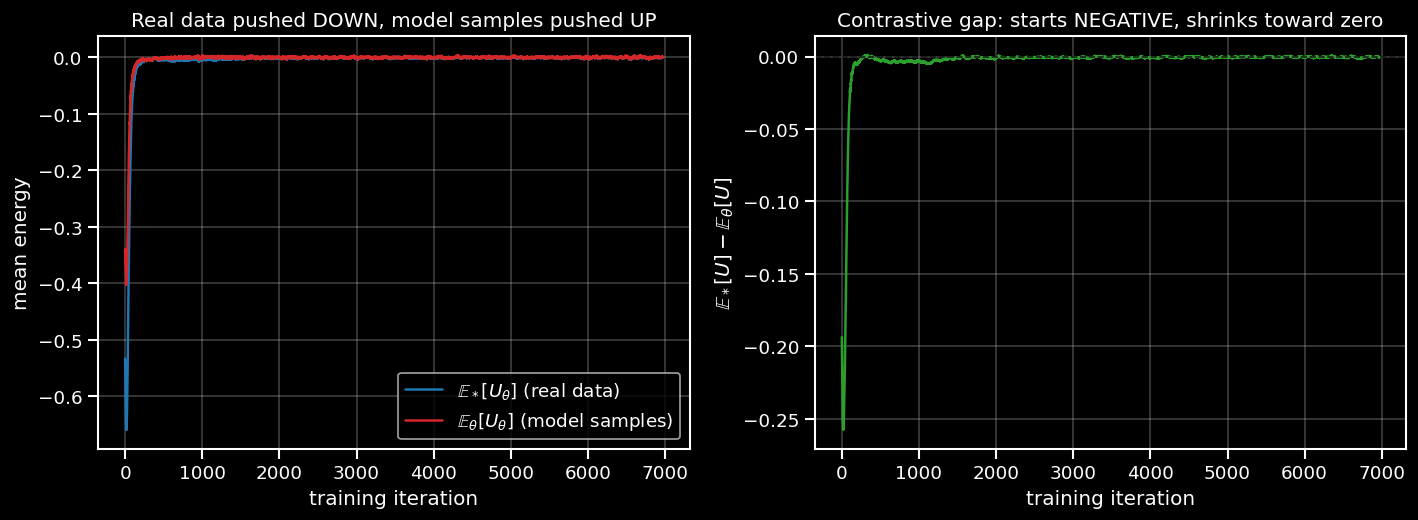

In [19]:
def smooth(v, w=50):
    v = np.array(v)
    if len(v) < w:
        return v
    return np.convolve(v, np.ones(w) / w, mode="valid")


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=120)

axes[0].plot(smooth(history["U_data"]),
             label="$\\mathbb{E}_*[U_\\theta]$ (real data)", color="#1f77b4")
axes[0].plot(smooth(history["U_sample"]),
             label="$\\mathbb{E}_\\theta[U_\\theta]$ (model samples)", color="#d62728")
axes[0].set_xlabel("training iteration"); axes[0].set_ylabel("mean energy")
axes[0].set_title("Real data pushed DOWN, model samples pushed UP")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(smooth(history["loss"]), color="#2ca02c")
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("training iteration")
axes[1].set_ylabel("$\\mathbb{E}_*[U] - \\mathbb{E}_\\theta[U]$")
axes[1].set_title("Contrastive gap: starts NEGATIVE, shrinks toward zero")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Notice the shape of the curves. Early on, the model samples (red) sit at much higher energy than the real data (blue): the buffer still contains noise, and the model is busy pushing that noise uphill while carving valleys under the digits. As training proceeds, the Langevin chains find their way into the valleys, and the two curves approach each other.

The <span style="color:red;"><strong>contrastive gap in the second panel therefore starts clearly negative</strong></span> and only *then* shrinks toward zero. This ensures that the starting point for the Markov Chain is not from real data points (since otherwise it will stay there due to them being at the lowest energies possible)

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 6 — The energy landscape has learned to discriminate</h3>

Let's redo the "digits vs noise" histogram from Step 2, now with the trained energy:

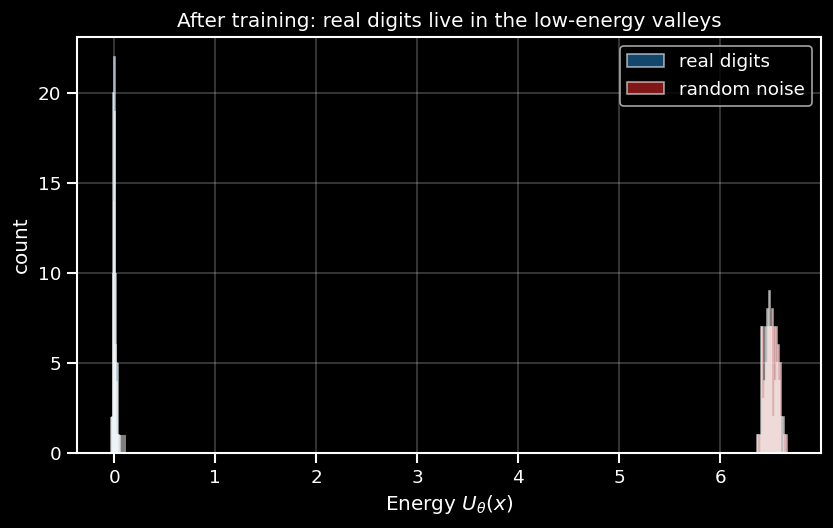

In [20]:
x_real, _ = next(iter(train_loader))
x_real = x_real.to(device)
x_noise = torch.rand_like(x_real) * 2 - 1

with torch.no_grad():
    U_real  = model(x_real).cpu().numpy()
    U_noise = model(x_noise).cpu().numpy()

plt.figure(figsize=(8, 4.5), dpi=120)
plt.hist(U_real,  bins=30, alpha=0.6, label="real digits",  color="#1f77b4")
plt.hist(U_noise, bins=30, alpha=0.6, label="random noise", color="#d62728")
plt.xlabel("Energy $U_\\theta(x)$")
plt.ylabel("count")
plt.title("After training: real digits live in the low-energy valleys")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

The histograms have split apart: the network has carved deep valleys in the 784-dimensional energy landscape exactly where the real digits live. 

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 7 — Generation: rolling downhill from pure noise</h3>

<span style="color:red;"><strong>Image generation process is jut like dropping a new particle in a fluid and let Langevin dynamics carry it into a valley of energy landscape.</strong></span>

We start from pure noise and run a much longer chain than during training (~2000 steps instead of 60), saving snapshots along the way so we can watch a digit condense out of the noise.


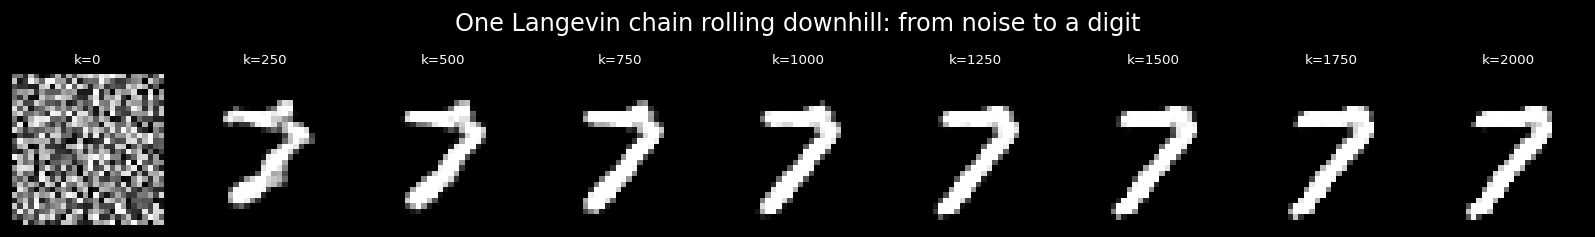

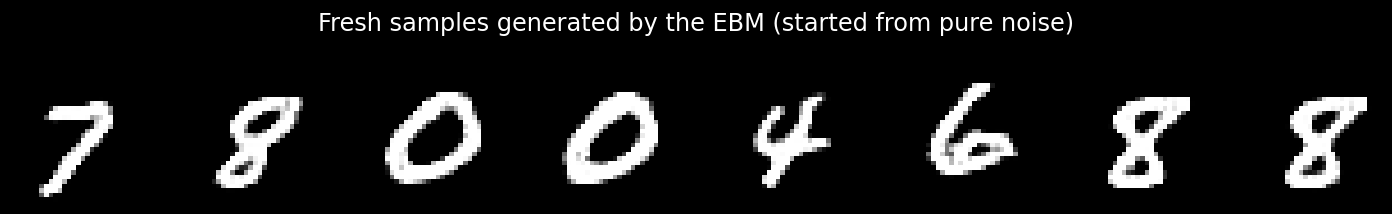

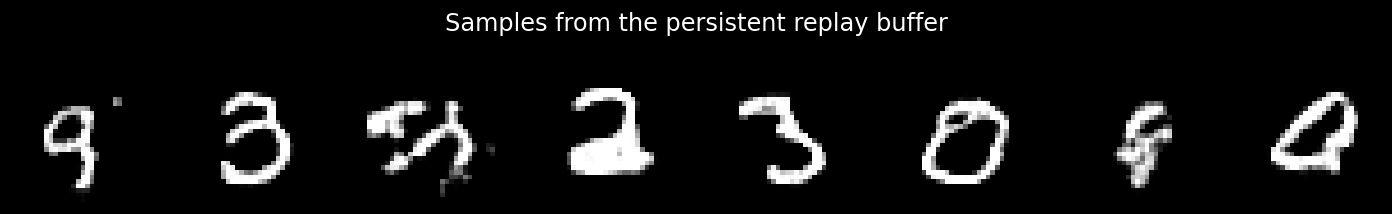

In [30]:
x_init = torch.rand(8, 1, 28, 28, device=device) * 2 - 1
x_gen, snaps = langevin_sample(
    model, x_init,
    n_steps=LANGEVIN_STEPS_GEN,
    snap_every=LANGEVIN_STEPS_GEN // 8,
)

# Evolution of one chain: noise -> digit
fig, axes = plt.subplots(1, len(snaps), figsize=(1.5 * len(snaps), 2.0), dpi=120)
for i, (ax, s) in enumerate(zip(axes, snaps)):
    ax.imshow(s[0, 0] * 0.5 + 0.5, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"k={i * (LANGEVIN_STEPS_GEN // 8)}", fontsize=8)
    ax.axis("off")
fig.suptitle("One Langevin chain rolling downhill: from noise to a digit")
plt.tight_layout()
plt.show()

show_images(x_gen, "Fresh samples generated by the EBM (started from pure noise)")

# Bonus: samples straight from the replay buffer are usually the best-looking
# ones, since those chains have been refined across many training iterations.
show_images(buffer[:8].to(device), "Samples from the persistent replay buffer")

In [23]:
# Build an actual animation (not just a static filmstrip) of one chain
# rolling downhill from noise to a digit. Most of the interesting motion
# happens early, so we snapshot densely through the first 500 steps and
# coarsely afterwards, once the chain has essentially settled.
import matplotlib.animation as animation
from IPython.display import HTML

anim_steps = sorted(set(
    list(range(0, 501, 5)) +                          # dense: the "cool part"
    list(range(500, LANGEVIN_STEPS_GEN + 1, 50))       # coarse: slow settling
))

x_init_anim = torch.rand(1, 1, 28, 28, device=device) * 2 - 1
_, anim_snaps = langevin_sample(
    model, x_init_anim,
    n_steps=LANGEVIN_STEPS_GEN,
    snap_steps=anim_steps,
)
frame_steps = [0] + anim_steps                          # snaps[0] is k=0 (pure noise)
frames = [s[0, 0] * 0.5 + 0.5 for s in anim_snaps]       # back to [0, 1] for display

# Hold on the first/last frame briefly so the eye registers "noise" and
# "digit" instead of the transition just flashing by.
hold_start, hold_end = 6, 15
frame_order = [0] * hold_start + list(range(len(frames))) + [len(frames) - 1] * hold_end

fig, ax = plt.subplots(figsize=(3, 3), dpi=120)
im = ax.imshow(frames[0], cmap="gray", vmin=0, vmax=1)
step_title = ax.set_title(f"k = 0 / {LANGEVIN_STEPS_GEN}", fontsize=10)
ax.axis("off")

def update(i):
    im.set_data(frames[i])
    step_title.set_text(f"k = {frame_steps[i]} / {LANGEVIN_STEPS_GEN}")
    return im, step_title

ani = animation.FuncAnimation(fig, update, frames=frame_order, interval=80, blit=False)
plt.close(fig)

ani.save("langevin_evolution.gif", writer="pillow", fps=15)
HTML(ani.to_jshtml())


Compared to a diffusion model this is a small, primitive setup. However, conceptually we have just implemented, end to end, the same pipeline that powers modern generative AI: a learned landscape plus a stochastic process that samples from it.

###
<h3 style="color: #2980b9; border-bottom: 2px dashed #bdc3c7; padding-bottom: 8px; margin-top: 25px; font-weight: 600;">✨ Step 8 — Sanity check: energies of generated vs real images</h3>

Finally, if the model distribution really matches the data distribution, generated samples should sit at energies comparable to real digits:

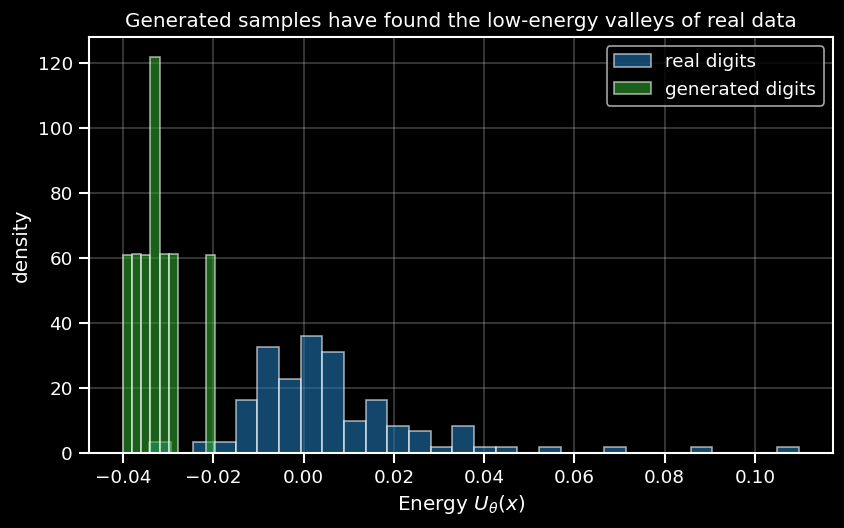

In [31]:
with torch.no_grad():
    U_gen = model(x_gen).cpu().numpy()

plt.figure(figsize=(8, 4.5), dpi=120)
plt.hist(U_real, bins=30, alpha=0.6, density=True,
         label="real digits", color="#1f77b4")
plt.hist(U_gen,  bins=10, alpha=0.6, density=True,
         label="generated digits", color="#2ca02c")
plt.xlabel("Energy $U_\\theta(x)$")
plt.ylabel("density")
plt.title("Generated samples have found the low-energy valleys of real data")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">Training using Score Matching Method (Sampling-Free Methods)</h2></div>

Another useful training method that is even more practical than Contrastive Divergence. We only lay down the theory of this method. 

Implementation of it should be straightforward and is left as an exercise.

If sampling is too costly, we can alter the objective function to avoid it entirely and <span style="color:red;"><strong>Score Matching</strong></span> is a prominent example. 

In this method, the loss function is no longer cross entropy. 
Instead of matching the model and data probabilities directly, we minimize the squared difference between the gradients of the log-densities (known as the "score"):

$$
\mathcal{L}_{\text{SM}} \;=\; \frac{1}{2}\,\mathbb{E}_{*}\Big[\,\big\|\nabla_{x}\log\rho_{*}(x) \;-\; \nabla_{x}\log\rho_{\theta}(x)\big\|^{2}\,\Big]

$$

where the model's score is defined as

$$
s_{\theta}(x) = \nabla_{x}\log\rho_{\theta}(x) = -\nabla_{x}U_{\theta}(x).
$$

At this point, a careful reader might say that this objective still contains the *unknown* data score $\nabla_x \log \rho_*$. 
But, an integration by parts eliminates it. Assuming $\rho_*$ vanishes at infinity, here are the step:

<span style="color:red;"><strong>Step 1: Expand the square.</strong></span> Writing $s_*(x) = \nabla_x \log \rho_*(x)$ for the data score, the objective is

$$
\mathcal{L}_{\text{SM}} = \frac{1}{2}\mathbb{E}_{*}\big\|s_* + \nabla U_\theta\big\|^2
= \underbrace{\frac{1}{2}\mathbb{E}_{*}\|s_*\|^2}_{\text{no dependence on }\theta}
\;+\; \mathbb{E}_{*}\big[ s_* \nabla U_\theta \big]
\;+\; \frac{1}{2}\mathbb{E}_{*}\|\nabla U_\theta\|^2.
$$

The first term is a property of the data alone and has no $\theta$ dependence, so it's an additive constant we can drop. 
The last term is already computable from samples. Only the cross term still contains the unknown $s_*$.

<span style="color:red;"><strong>Step 2: Kill the data score in the cross term.</strong></span> The trick is the identity $\rho_* \nabla \log \rho_* = \nabla \rho_*$, which converts the expectation into a plain integral against $\nabla\rho_*$:

$$
\mathbb{E}_{*}\big[ s_*, \nabla U_\theta \big]
= \int \rho_*(x)\, \nabla \log \rho_*(x)\, \nabla U_\theta(x)\, dx
= \int \nabla \rho_*(x)\, \nabla U_\theta(x)\, dx.
$$

Now integrate by parts (component-wise, i.e. apply the divergence theorem). The boundary term vanishes by the decay assumption $\rho_*(x)\,\nabla U_\theta(x) \to 0$ as $\|x\|\to\infty$, leaving

$$
\int  \nabla \rho_* \nabla U_\theta\, dx
= -\int \rho_*(x)\, \Delta U_\theta(x)\, dx
= -\,\mathbb{E}_{*}\big[\Delta U_\theta\big].
$$

<span style="color:red;"><strong>Step 3: Assemble.</strong></span>

$$
\mathcal{L}_{\text{SM}} = \mathbb{E}_{*}\!\left[\frac{1}{2}\|\nabla U_\theta\|^2 - \Delta U_\theta\right] + \text{const}.
$$

where $\Delta = \nabla\cdot\nabla$ is the Laplacian (trace of the Hessian). This form involves only the model energy $U_\theta$ evaluated on training samples, i.e. no data score, no $Z_\theta$, and no sampling.

Because taking the derivative of the log-density eliminates the constant $\log Z_{\theta}$ term, the objective becomes perfectly tractable. <span style="color:red;"><strong>The major trade-off of sampling-free methods</strong></span> is that they do not estimate $Z_{\theta}$ at all, meaning the model learns an unnormalized density and cannot be used for tasks that require exact likelihood evaluations.







##
<div style="border-left: 8px solid #e74c3c; background: linear-gradient(to right, #fdfefe, #f4f6f7); padding: 12px 20px; margin: 35px 0 20px 0; border-radius: 4px; box-shadow: 0 2px 8px rgba(0,0,0,0.06);"><h2 style="color: #2c3e50; margin: 0; font-weight: 700;">References</h2></div>

[1] [LeCun, Y., Chopra, S., Hadsell, R., Ranzato, M., & Huang, F. (2006). A tutorial on energy-based learning. Predicting structured data, 1(0), 1-59.](References/A%20Tutorial%20on%20Energy-Based%20Learning.pdf)

[2] [Pierobon, I. V., et al. (2020). Hitchhiker's guide on Energy-Based Models.](References/Hitchhiker’s%20guide%20on%20Energy-Based%20Models.pdf)